# SSGrad-CAM++ dla RF-DETR (implementacja własna)

Gradient-based saliency na poziomie detekcji; implementacja bez zewnętrznych bibliotek CAM.

**Schemat działania:**

```
predict() detekcja  →  IoU match do raw query
  →  target_score = raw_logit[query_id, class_id]
  →  backward
  →  SSGrad-CAM++ z C2f.cv2 (ta sama warstwa co GradCAM++ / EigenCAM)
```

**Kluczowa różnica względem GradCAM++:**

SSGrad-CAM++ mnoży mapę przez **spatial sensitivity map** znormalizowaną z `abs(grad)`:

$$\text{space\_maps} = \frac{|\nabla A|}{\max(|\nabla A|)}$$

$$\text{CAM} = \text{ReLU}\!\left(\sum_k \bigl(w^k \cdot A^k \cdot \text{space\_maps}^k\bigr)\right)$$

**Matematyka SSGrad-CAM++ (Grad-CAM++ alpha):**

$$\alpha_{ij}^k = \frac{(\partial^2 S / \partial (A_{ij}^k)^2)}{2(\partial^2 S)^2 + \sum_{mn \in M} A_{mn}^k (\partial^3 S)}$$

gdzie $M$ to target region mask (piksele z niezerowym gradientem).

$$w^k = \sum_{ij} \alpha_{ij}^k \cdot \text{ReLU}\!\left(\frac{\partial S}{\partial A_{ij}^k}\right)$$

Implementacja bazuje na: *Spatial Sensitive Grad-CAM++: Improved Visual Explanation for Object Detectors via Weighted Combination of Gradient Map*, CVPR Workshop 2024.

**Uwaga metodologiczna:** tak jak GradCAM++, SSGrad-CAM++ jest **per-detection** — zawsze backpropagujemy od surowego logitu dopasowanego query. Nie rób SSGrad-CAM++ dla losowego query.

In [51]:
from pathlib import Path
import os
import sys
import site

def find_repo_root(marker="pyproject.toml", max_depth=10):
    current = Path.cwd().resolve()
    for _ in range(max_depth):
        if (current / marker).exists():
            return current
        current = current.parent
    return None

def prefer_venv_site_packages():
    venv_prefix = str(Path(sys.prefix).resolve())
    venv_sites = [p for p in site.getsitepackages() if p.startswith(venv_prefix)]
    cleaned = [p for p in sys.path if not (p.startswith("/net/software/") and "site-packages" in p)]
    for p in reversed(venv_sites):
        if p in cleaned:
            cleaned.remove(p)
        cleaned.insert(0, p)
    sys.path[:] = cleaned
    cached = sys.modules.get("regex")
    cached_path = getattr(cached, "__file__", "") if cached is not None else ""
    if cached_path.startswith("/net/software/"):
        for name in list(sys.modules.keys()):
            if name == "regex" or name.startswith("regex."):
                del sys.modules[name]

REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    REPO_ROOT = Path("/net/tscratch/people/plgbmruszaj/dermatoscopy_ai")

RFD_XAI_ROOT = REPO_ROOT / "dermato_ai" / "rfdetr-xai"
os.chdir(RFD_XAI_ROOT)
sys.path.insert(0, str(RFD_XAI_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT))
prefer_venv_site_packages()

from dermato_ai.coco.dataset_manager import COCODatasetManager

DATA_ZIP_DIR = REPO_ROOT / "data" / "coco_images_zip"
manager = COCODatasetManager.from_archive(directory=DATA_ZIP_DIR, archive_pattern="*.zip")
dataset_dir = Path(manager.json_path).parent
dedup_coco_json = dataset_dir / "result_dedup_for_ssgradcampp.json"
manager.save(str(dedup_coco_json))

COCO_JSON   = str(dedup_coco_json)
IMAGES_DIR  = str(dataset_dir / "images")
CHECKPOINT  = "/net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth"
OUTPUT_DIR  = RFD_XAI_ROOT / "wyniki" / "rfdetr_ssgradcampp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Python:", sys.executable)
print("✓ COCO JSON:", COCO_JSON)
print("✓ Images:", IMAGES_DIR)
print("✓ Checkpoint:", CHECKPOINT)
print("✓ Output dir:", OUTPUT_DIR)

INFO: Found newest archive: project-5-at-2026-05-07-11-56-9b7fa76c.zip
INFO: Unpacking project-5-at-2026-05-07-11-56-9b7fa76c.zip to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted


INFO: Extraction complete
INFO: Found result.json at: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loading COCO dataset from /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loaded 314 images, 1299 annotations
INFO: Collapsed duplicate image passes: removed 97 image entries and 0 annotations
INFO: Valid COCO structure: 217 images, 1299 annotations, 10 categories
INFO: Fixed 217 image paths
INFO: Saved dataset to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_ssgradcampp.json


✓ Python: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/.venv/bin/python
✓ COCO JSON: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_ssgradcampp.json
✓ Images: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/images
✓ Checkpoint: /net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth
✓ Output dir: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp


## Konfiguracja

In [52]:
THRESHOLD     = 0.25   # próg detekcji dla predict()
MIN_MATCH_IOU = 0.3    # minimalny IoU query↔detection; niższy → skip
CLASS_AWARE   = True   # wymagaj zgodności klasy przy dopasowaniu query
CAM_ALPHA     = 0.45   # przezroczystość overlay

# Cel backward: False → surowy logit (standard); True → sigmoid(logit)
USE_SIGMOID_TARGET = False

# Dwie domyślne warstwy:
#   główna  — ostatnia konwolucja C2f projektora; pełna reprezentacja po bottleneckach
#   ideowa  — wyjście całego MultiScaleProjector; szerszy kontekst przestrzenny
TARGET_LAYER_MAIN = "backbone.0.projector.stages.0.0.cv2"  # główna / finalna
TARGET_LAYER_REF  = "backbone.0.projector"                  # referencyjna / ideowa

# Indeks obrazu w posortowanej liście (zmień, by zobaczyć inny obraz)
IMAGE_IDX = 0

## Ładowanie modelu i obrazu

In [53]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import torch
import torch.nn.functional as F
from PIL import Image

from rfdetr_load import load_rfdetr
from rfdetr_gradcampp_custom import (
    cam_quality_status,
    match_detection_to_query,
    preprocess_for_gradcampp,
    overlay_cam_on_image,
    resolve_rfdetr_device,
    inspect_candidate_cam_layers,
    default_target_layer_name,
    get_module_by_name,
    DEFAULT_CAM_TARGET_LAYER_NAME,
)
from xai_metrics import (
    pointing_game_hit,
    energy_fraction_inside_bbox,
    energy_enrichment_inside_bbox,
)

try:
    from IPython.display import display
except ImportError:
    display = print

model = load_rfdetr("large", CHECKPOINT)

all_images = sorted(Path(IMAGES_DIR).glob("*"))
image_path = all_images[IMAGE_IDX]
pil_img    = Image.open(image_path).convert("RGB")
image_rgb  = np.array(pil_img)

print(f"✓ Model załadowany")
print(f"✓ Obraz: {image_path.name}  ({pil_img.width}×{pil_img.height} px)")

[2026-05-08 10:00:01] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-08 10:00:01] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-08 10:00:02] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.


✓ Model załadowany
✓ Obraz: 0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg  (1920×1080 px)


## Weryfikacja warstwy docelowej

Ta sama warstwa co GradCAM++ i EigenCAM: `C2f.cv2` z pierwszego etapu `MultiScaleProjector`.

In [54]:
inner  = model.model.model
device = resolve_rfdetr_device(model)
batch_tensor, orig_hw, input_hw = preprocess_for_gradcampp(model, pil_img)

# image_hw = rozmiar oryginalnego obrazu (H, W) — stosowany jako output_hw CAM
image_hw = orig_hw

# TARGET_LAYER_NAME = aktywna warstwa dla poniższych komórek (domyślnie główna)
TARGET_LAYER_NAME = TARGET_LAYER_MAIN

target_layer = get_module_by_name(inner, TARGET_LAYER_NAME)

print("✓ Warstwa główna (TARGET_LAYER_MAIN):", TARGET_LAYER_MAIN)
print("✓ Warstwa referencyjna (TARGET_LAYER_REF):", TARGET_LAYER_REF)
print("✓ Aktywna (TARGET_LAYER_NAME):", TARGET_LAYER_NAME)
print(f"  └─ {target_layer.__class__.__name__}")
print(f"✓ Urządzenie modelu (z parametrów): {device}")
print(f"✓ Batch device: {batch_tensor.device}  dtype: {batch_tensor.dtype}")
print(f"✓ orig_hw={orig_hw}  input_hw={input_hw}")

# Probe: kształty aktywacji obu warstw
def _probe_activation_shape(layer_name):
    layer = get_module_by_name(inner, layer_name)
    captured = []
    def _hook(module, inputs, output):
        t = _extract_first_tensor(output)
        if t is not None:
            captured.append(tuple(t.shape))
    handle = layer.register_forward_hook(_hook)
    try:
        with torch.no_grad():
            _ = inner(batch_tensor)
    finally:
        handle.remove()
    return captured[0] if captured else None

for lname in (TARGET_LAYER_MAIN, TARGET_LAYER_REF):
    shape = _probe_activation_shape(lname)
    tag   = "(główna)" if lname == TARGET_LAYER_MAIN else "(referencyjna)"
    print(f"  Kształt aktywacji {tag}: {shape}  ← {lname}")

✓ Warstwa główna (TARGET_LAYER_MAIN): backbone.0.projector.stages.0.0.cv2
✓ Warstwa referencyjna (TARGET_LAYER_REF): backbone.0.projector
✓ Aktywna (TARGET_LAYER_NAME): backbone.0.projector.stages.0.0.cv2
  └─ ConvX
✓ Urządzenie modelu (z parametrów): cpu
✓ Batch device: cpu  dtype: torch.float32
✓ orig_hw=(1080, 1920)  input_hw=(704, 704)
  Kształt aktywacji (główna): (1, 256, 44, 44)  ← backbone.0.projector.stages.0.0.cv2


  Kształt aktywacji (referencyjna): (1, 256, 44, 44)  ← backbone.0.projector


### Kandydaci warstw CAM (do sweepu)

`inspect_candidate_cam_layers` zwraca wyłącznie wyjścia **4D** `[B, C, H, W]`. Baseline: **`DEFAULT_CAM_TARGET_LAYER_NAME`**. Wybrane nazwy wklej do `CANDIDATE_LAYER_NAMES` w sweepie.

In [55]:
print("Kanoniczna warstwa CAM (baseline):", DEFAULT_CAM_TARGET_LAYER_NAME)
print("Rozwiązana domyślna nazwa w tym modelu:", TARGET_LAYER_NAME)

candidates = inspect_candidate_cam_layers(model, pil_img)
print(f"\nLiczba kandydatów 4D: {len(candidates)}\n")
for name, cls_name, shape in sorted(candidates, key=lambda x: x[0])[:80]:
    print(f"  {name:85s} | {cls_name:28s} | {shape}")
if len(candidates) > 80:
    print(f"  ... i {len(candidates) - 80} więcej")

CANDIDATE_LAYER_NAMES = [r[0] for r in candidates]

Kanoniczna warstwa CAM (baseline): backbone.0.projector.stages.0.0.cv2
Rozwiązana domyślna nazwa w tym modelu: backbone.0.projector.stages.0.0.cv2

Liczba kandydatów 4D: 48

  backbone                                                                              | Joiner                       | (1, 256, 44, 44)
  backbone.0.encoder                                                                    | DinoV2                       | (1, 384, 44, 44)
  backbone.0.encoder.encoder                                                            | WindowedDinov2WithRegistersBackbone | (1, 384, 44, 44)
  backbone.0.encoder.encoder.embeddings.patch_embeddings.projection                     | Conv2d                       | (1, 384, 44, 44)
  backbone.0.projector                                                                  | MultiScaleProjector          | (1, 256, 44, 44)
  backbone.0.projector.stages.0                                                         | Sequential                   | (1, 256,

## Implementacja SSGrad-CAM++

Poniżej kompletna implementacja Spatial Sensitive Grad-CAM++ jako samodzielne funkcje (bez zewnętrznych bibliotek CAM).

Kluczowe elementy:
- `ForwardActivationHook` — rejestruje aktywację i zachowuje grad (`.retain_grad()`)
- `compute_ssgradcampp_from_activation` — rdzeń SSGrad-CAM++: alpha, weights, spatial sensitivity map
- `compute_rfdetr_ssgradcampp_for_detection` — high-level runner: predict → match → backward → CAM

In [56]:
def _extract_first_tensor(output):
    if torch.is_tensor(output):
        return output
    if isinstance(output, (list, tuple)):
        for item in output:
            t = _extract_first_tensor(item)
            if t is not None:
                return t
    if isinstance(output, dict):
        for item in output.values():
            t = _extract_first_tensor(item)
            if t is not None:
                return t
    return None


def activation_to_bchw(tensor: torch.Tensor, explicit_hw=None):
    """
    Obsługuje:
    - [B, C, H, W]
    - [B, N, C] dla tokenów ViT (jeśli sqrt(N) jest całkowite, lub N-1 po odcięciu CLS)
    """
    if tensor.dim() == 4:
        return tensor
    if tensor.dim() == 3:
        b, n, c = tensor.shape
        if explicit_hw is not None:
            h, w = explicit_hw
            if h * w != n:
                raise ValueError(f"explicit_hw={explicit_hw} does not match N={n}")
            return tensor.reshape(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        root = int(math.sqrt(n))
        if root * root == n:
            h = w = root
            return tensor.reshape(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        root = int(math.sqrt(n - 1))
        if root * root == n - 1:
            h = w = root
            return tensor[:, 1:, :].reshape(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        raise ValueError(f"Cannot reshape token tensor {tuple(tensor.shape)} to spatial map.")
    raise ValueError(f"Unsupported activation shape: {tuple(tensor.shape)}")


class ForwardActivationHook:
    """Context manager: rejestruje aktywację z warstwy i zachowuje jej grad."""

    def __init__(self, module: torch.nn.Module):
        self.module    = module
        self.activation = None
        self.handle    = None

    def __enter__(self):
        def hook(module, inputs, output):
            tensor = _extract_first_tensor(output)
            if tensor is None:
                raise RuntimeError("Target layer output does not contain a tensor.")
            self.activation = tensor
            self.activation.retain_grad()
        self.handle = self.module.register_forward_hook(hook)
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        if self.handle is not None:
            self.handle.remove()


def compute_ssgradcampp_from_activation(
    activation: torch.Tensor,
    gradient: torch.Tensor,
    output_hw: tuple,
    eps: float = 1e-7,
) -> np.ndarray:
    """
    Rdzeń Spatial Sensitive Grad-CAM++.

    Różnica względem GradCAM++:
    - GradCAM++: CAM = sum_k(w^k * A^k)
    - SSGrad-CAM++: CAM = sum_k(w^k * A^k * spatial_sensitivity^k)

    spatial_sensitivity = abs(grad) / max(abs(grad))  — wzmacnia przestrzennie
    ważne miejsca gradientu.
    """
    act  = activation_to_bchw(activation)  # [B, C, H, W]
    grad = activation_to_bchw(gradient)    # [B, C, H, W]

    if act.shape != grad.shape:
        raise ValueError(f"Activation and gradient shapes differ: {act.shape} vs {grad.shape}")

    second_derivative = grad * grad
    third_derivative  = second_derivative * grad

    # Target region mask: piksel aktywny ↔ dowolny kanał ma niezerowy gradient
    target_regions = (torch.sum(torch.abs(grad) > 0, dim=1, keepdim=True) > 0).float()

    feature_target = act * target_regions
    conv_sum       = torch.sum(feature_target, dim=(2, 3), keepdim=True)

    alpha_num   = second_derivative
    alpha_denom = 2.0 * second_derivative * target_regions + conv_sum * third_derivative + eps
    alpha       = alpha_num / alpha_denom
    alpha       = torch.where(torch.isfinite(alpha), alpha, torch.zeros_like(alpha))
    alpha       = torch.where(grad != 0, alpha, torch.zeros_like(alpha))

    weights = alpha * torch.relu(grad)
    weights = torch.sum(weights, dim=(2, 3), keepdim=True)  # [B, C, 1, 1]

    # Spatial sensitivity map: abs(grad) znormalizowane do [0,1] per-batch
    grad_abs     = torch.abs(grad)
    grad_abs_max = torch.amax(grad_abs, dim=(2, 3), keepdim=True)
    space_maps   = torch.where(
        grad_abs_max > 0,
        grad_abs / (grad_abs_max + eps),
        torch.zeros_like(grad_abs),
    )

    cam = act * weights * space_maps          # instance-sensitive modulation
    cam = torch.sum(cam, dim=1, keepdim=True) # [B, 1, H, W]
    cam = torch.relu(cam)

    cam = F.interpolate(cam, size=output_hw, mode="bilinear", align_corners=False)

    cam = cam[0, 0]
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam.detach().cpu().numpy().astype(np.float32)

In [57]:
def compute_rfdetr_ssgradcampp_for_detection(
    rf_model,
    batch_tensor: torch.Tensor,
    pred_detections,
    det_index: int,
    image_hw: tuple,
    target_layer_name: str,
    min_match_iou: float = 0.3,
    use_sigmoid_target: bool = False,
    class_aware: bool = True,
) -> tuple:
    """
    SSGrad-CAM++ dla konkretnej detekcji RF-DETR.

    Pipeline:
      predict() detection
        → IoU match do raw query
        → target = raw logit matched query/class
        → backward do target layer
        → SSGrad-CAM++

    Parametry
    ----------
    image_hw:           (H, W) oryginalnego obrazu — rozmiar wyjściowej mapy CAM.
    target_layer_name:  pełna nazwa modułu z inner.named_modules().
    """
    # input_hw odczytujemy z kształtu batcha: [1, 3, H_in, W_in]
    input_hw = (int(batch_tensor.shape[2]), int(batch_tensor.shape[3]))

    core         = rf_model.model.model
    target_layer = get_module_by_name(core, target_layer_name)

    # model.predict() może przenieść model na GPU po wczytaniu; synchronizujemy urządzenie
    try:
        _core_device = next(core.parameters()).device
    except StopIteration:
        _core_device = batch_tensor.device
    if batch_tensor.device != _core_device:
        batch_tensor = batch_tensor.to(_core_device)

    core.zero_grad(set_to_none=True)
    core.eval()

    with ForwardActivationHook(target_layer) as hook:
        outputs = core(batch_tensor)
        if isinstance(outputs, tuple):
            outputs = {"pred_logits": outputs[1], "pred_boxes": outputs[0]}

        match = match_detection_to_query(
            pred_detections=pred_detections,
            det_idx=det_index,
            raw_outputs=outputs,
            orig_hw=image_hw,
            input_hw=input_hw,
            class_aware=class_aware,
        )

        if match["pred_confidence"] < THRESHOLD:
            raise RuntimeError(
                f"Detection confidence {match['pred_confidence']:.4f} < THRESHOLD={THRESHOLD}"
            )

        if match["matched_iou"] < min_match_iou:
            raise RuntimeError(
                f"Matched IoU {match['matched_iou']:.4f} < min_match_iou={min_match_iou}"
            )

        query_id   = match["query_id"]
        class_id   = match["logit_class_id"]
        raw_logit  = outputs["pred_logits"][0, query_id, class_id]
        target_score = raw_logit.sigmoid() if use_sigmoid_target else raw_logit
        target_score.backward(retain_graph=False)

        activation = hook.activation
        gradient   = hook.activation.grad

        if activation is None or gradient is None:
            raise RuntimeError("Could not capture activation/gradient from target layer.")

        cam = compute_ssgradcampp_from_activation(
            activation=activation,
            gradient=gradient,
            output_hw=image_hw,
        )

    match_out = {
        **match,
        "target_layer_name": target_layer_name,
        "use_sigmoid_target": use_sigmoid_target,
        "method": "SSGrad-CAM++",
    }
    return cam, match_out


def class_label_for_id(rf_model, class_id: int) -> str:
    """Nazwa klasy dla danego class_id (fallback: str(class_id))."""
    return str(class_id)

## Funkcje wizualizacji

Panel 3-częściowy: detekcja | heatmapa SSGrad-CAM++ | overlay.

In [58]:
def _draw_box(image_rgb: np.ndarray, box_xyxy, color=(0, 255, 0), thickness=3):
    out = image_rgb.copy()
    x1, y1, x2, y2 = [int(round(v)) for v in box_xyxy]
    cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
    return out


def draw_box_on_heatmap(cam: np.ndarray, box_xyxy, color=(0, 255, 0), thickness=3):
    cam_uint8   = np.uint8(255 * np.clip(cam, 0.0, 1.0))
    heatmap_bgr = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
    x1, y1, x2, y2 = [int(round(v)) for v in box_xyxy]
    cv2.rectangle(heatmap_rgb, (x1, y1), (x2, y2), color, thickness)
    return heatmap_rgb


def make_ssgradcampp_figure(
    image_rgb: np.ndarray,
    cam: np.ndarray,
    match: dict,
    class_name: str,
    cam_quality: str | None = None,
):
    box = match["box_orig_xyxy"]
    overlay      = overlay_cam_on_image(image_rgb, cam, alpha=CAM_ALPHA)
    overlay_box  = _draw_box(overlay, box)
    heatmap_box  = draw_box_on_heatmap(cam, box)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(_draw_box(image_rgb, box))
    axes[0].set_title("Target detection")
    axes[0].axis("off")

    axes[1].imshow(heatmap_box)
    axes[1].set_title("SSGrad-CAM++ + target box")
    axes[1].axis("off")

    axes[2].imshow(overlay_box)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    qual = f"  quality={cam_quality}" if cam_quality else ""
    fig.suptitle(
        f"SSGrad-CAM++  det={match['det_idx']}  query={match['query_id']}  "
        f"class={class_name}  conf={match['pred_confidence']:.4f}  "
        f"IoU(query)={match['matched_iou']:.3f}{qual}"
    )
    plt.tight_layout()
    return fig


def save_ssgradcampp_result(
    image_rgb: np.ndarray,
    cam: np.ndarray,
    match: dict,
    class_name: str,
    out_dir: Path,
    stem: str,
    cam_quality: str | None = None,
    extra_meta: dict | None = None,
) -> Path:
    """Zapisuje PNG + npy + JSON; zwraca ścieżkę do PNG."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    np.save(out_dir / f"{stem}.npy", cam)

    fig = make_ssgradcampp_figure(image_rgb, cam, match, class_name, cam_quality=cam_quality)
    png_path = out_dir / f"{stem}.png"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    meta = {"method": "SSGrad-CAM++", **match, "class_name": class_name}
    if cam_quality:
        meta["cam_quality"] = cam_quality
    if extra_meta:
        meta.update(extra_meta)
    (out_dir / f"{stem}.json").write_text(
        json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    return png_path

## Detekcje z predict()

In [59]:
det = model.predict(pil_img, threshold=THRESHOLD)

if det is None or len(det) == 0:
    print(f"⚠ Brak detekcji (threshold={THRESHOLD}). Zmień IMAGE_IDX lub obniż THRESHOLD.")
else:
    print(f"✓ Znaleziono {len(det)} detekcji:")
    for i in range(len(det)):
        cls_id = int(det.class_id[i])
        conf   = float(det.confidence[i])
        box    = [round(v, 1) for v in det.xyxy[i].tolist()]
        print(f"  det={i}  class_id={cls_id}  conf={conf:.4f}  box={box}")

[2026-05-08 10:00:04] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


✓ Znaleziono 4 detekcji:
  det=0  class_id=0  conf=0.8513  box=[861.7, 713.1, 922.8, 812.9]
  det=1  class_id=0  conf=0.8155  box=[554.0, 488.9, 625.1, 652.4]
  det=2  class_id=0  conf=0.7669  box=[679.9, 821.2, 793.5, 875.2]
  det=3  class_id=0  conf=0.7176  box=[496.8, 800.7, 539.1, 896.9]


## SSGrad-CAM++ dla pierwszej detekcji

In [60]:
assert det is not None and len(det) > 0, "Brak detekcji — zatrzymaj wykonanie."

DET_IDX = 0

cam, match = compute_rfdetr_ssgradcampp_for_detection(
    rf_model=model,
    batch_tensor=batch_tensor,
    pred_detections=det,
    det_index=DET_IDX,
    image_hw=image_hw,
    target_layer_name=TARGET_LAYER_NAME,
    min_match_iou=MIN_MATCH_IOU,
    use_sigmoid_target=USE_SIGMOID_TARGET,
    class_aware=CLASS_AWARE,
)

class_name = class_label_for_id(model, match["pred_class_id"])

print("Match info:")
print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v) for k, v in match.items()}, indent=2))
print(f"\nCAM shape: {cam.shape}  min={cam.min():.4f}  max={cam.max():.4f}")

Match info:
{
  "det_idx": 0,
  "query_id": 0,
  "matched_iou": 0.9993,
  "pred_class_id": 0,
  "logit_class_id": 0,
  "pred_confidence": 0.8513,
  "raw_query_class_score": 0.8522,
  "box_orig_xyxy": [
    861.7444458007812,
    713.0776977539062,
    922.7802734375,
    812.891357421875
  ],
  "box_input_xyxy": [
    315.97296142578125,
    464.8210144042969,
    338.3527526855469,
    529.884765625
  ],
  "target_layer_name": "backbone.0.projector.stages.0.0.cv2",
  "use_sigmoid_target": false,
  "method": "SSGrad-CAM++"
}

CAM shape: (1080, 1920)  min=0.0000  max=1.0000


## Wizualizacja

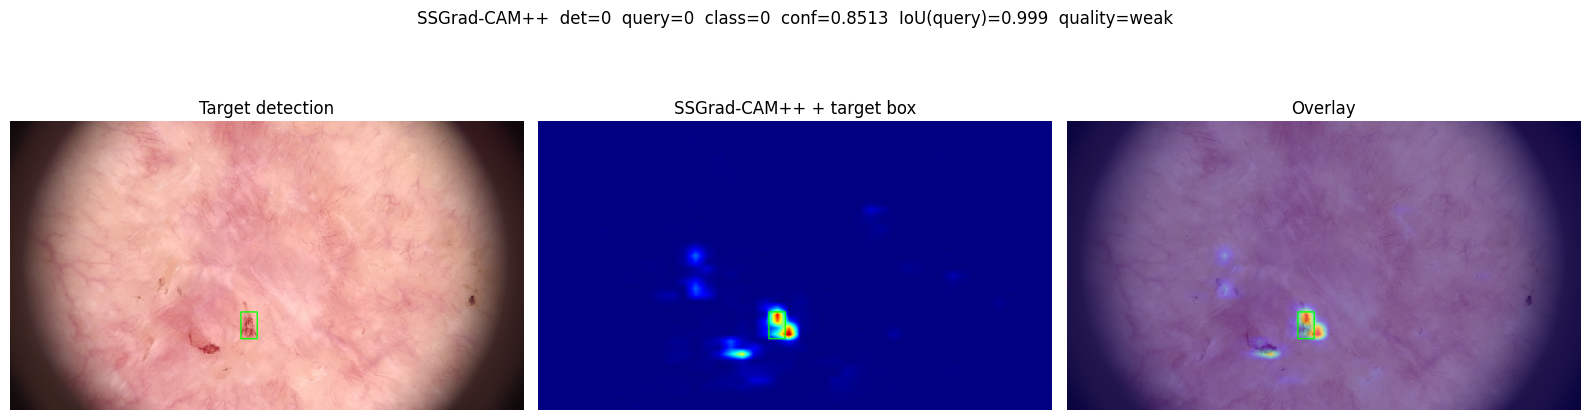

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/ssgradcampp_img0_det0_q0.png


In [61]:
box_xyxy    = tuple(match["box_orig_xyxy"])
hit_preview = pointing_game_hit(cam, box_xyxy)
ef_preview  = energy_fraction_inside_bbox(cam, box_xyxy)
qual        = cam_quality_status(hit_preview, ef_preview)

fig = make_ssgradcampp_figure(image_rgb, cam, match, class_name, cam_quality=qual)
plt.show()

stem     = f"ssgradcampp_img{IMAGE_IDX}_det{DET_IDX}_q{match['query_id']}"
png_path = save_ssgradcampp_result(
    image_rgb=image_rgb,
    cam=cam,
    match=match,
    class_name=class_name,
    out_dir=OUTPUT_DIR,
    stem=stem,
    cam_quality=qual,
    extra_meta={
        "threshold": THRESHOLD,
        "min_match_iou": MIN_MATCH_IOU,
        "image": image_path.name,
        "cam_quality": qual,
        "pointing_game": bool(hit_preview),
        "energy_fraction": float(ef_preview),
    },
)
print(f"✓ Zapisano: {png_path}")

## Metryki dla jednej detekcji

- **Pointing game** — czy szczyt mapy saliencji leży w bbox detekcji?
- **Energy fraction (EF)** — jaki ułamek energii mapy saliencji zawiera bbox?
- **Energy enrichment (EE)** — EF / (box_area / image_area); ≈1 → losowa, >1 → mapa preferuje box, <1 → omija.

In [62]:
box_xyxy = tuple(match["box_orig_xyxy"])

hit  = pointing_game_hit(cam, box_xyxy)
ef   = energy_fraction_inside_bbox(cam, box_xyxy)
ee   = energy_enrichment_inside_bbox(cam, box_xyxy)
qual = cam_quality_status(hit, ef)

print(f"Pointing game hit  : {hit}")
print(f"Energy fraction    : {ef:.4f}")
print(f"Energy enrichment  : {ee:.4f}  (baseline=1.0; >1→focuses on box, <1→avoids box)")
print(f"CAM quality label  : {qual}  (good / weak / failed — heurystyka)")
print(f"Matched IoU        : {match['matched_iou']:.4f}")
print(f"Query class score  : {match['raw_query_class_score']:.4f}")

Pointing game hit  : False
Energy fraction    : 0.1852
Energy enrichment  : 61.3413  (baseline=1.0; >1→focuses on box, <1→avoids box)
CAM quality label  : weak  (good / weak / failed — heurystyka)
Matched IoU        : 0.9993
Query class score  : 0.8522


### Porównanie: główna vs referencyjna warstwa (det=DET_IDX)

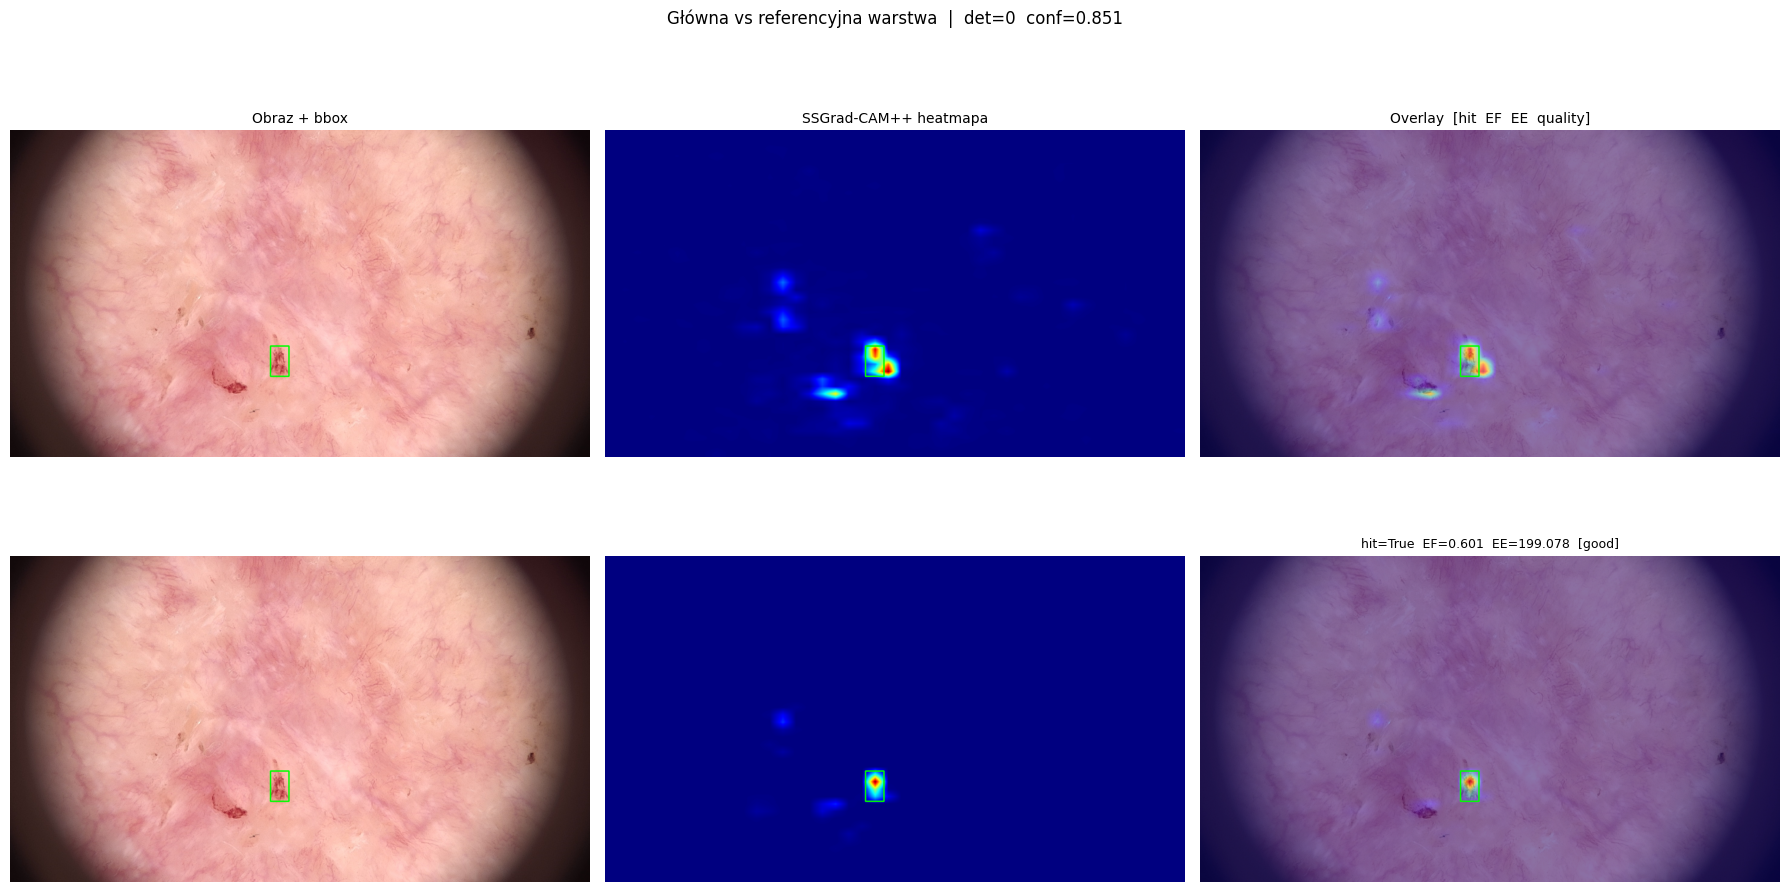

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/ssgradcampp_two_layer_compare_det0.png


In [63]:
_two_layers = [
    ("główna",      TARGET_LAYER_MAIN),
    ("referencyjna", TARGET_LAYER_REF),
]

_box_vis = tuple(match["box_orig_xyxy"])   # bbox z głównej warstwy (det=DET_IDX)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (tag, layer_name) in enumerate(_two_layers):
    ax_img, ax_heat, ax_over = axes[row]

    try:
        cam_cmp, match_cmp = compute_rfdetr_ssgradcampp_for_detection(
            rf_model=model,
            batch_tensor=batch_tensor,
            pred_detections=det,
            det_index=DET_IDX,
            image_hw=image_hw,
            target_layer_name=layer_name,
            min_match_iou=MIN_MATCH_IOU,
            use_sigmoid_target=USE_SIGMOID_TARGET,
            class_aware=CLASS_AWARE,
        )
        hit_c  = pointing_game_hit(cam_cmp, _box_vis)
        ef_c   = energy_fraction_inside_bbox(cam_cmp, _box_vis)
        ee_c   = energy_enrichment_inside_bbox(cam_cmp, _box_vis)
        qual_c = cam_quality_status(hit_c, ef_c)

        ax_img.imshow(_draw_box(image_rgb, _box_vis))
        ax_heat.imshow(draw_box_on_heatmap(cam_cmp, _box_vis))
        ax_over.imshow(_draw_box(overlay_cam_on_image(image_rgb, cam_cmp, alpha=CAM_ALPHA), _box_vis))
        ax_over.set_title(f"hit={hit_c}  EF={ef_c:.3f}  EE={ee_c:.3f}  [{qual_c}]", fontsize=9)

        stem_c = f"ssgradcampp_det{DET_IDX}_{layer_name.replace('.', '_')}_cmp"
        save_ssgradcampp_result(
            image_rgb=image_rgb, cam=cam_cmp, match=match_cmp,
            class_name=class_label_for_id(model, match_cmp["pred_class_id"]),
            out_dir=OUTPUT_DIR / "two_layer_compare",
            stem=stem_c, cam_quality=qual_c,
        )

    except Exception as exc:
        for ax in (ax_img, ax_heat, ax_over):
            ax.text(0.5, 0.5, str(exc), ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color="red")

    ax_img.set_ylabel(f"{tag}\n{layer_name}", fontsize=8, rotation=0, ha="right", va="center")
    for ax in (ax_img, ax_heat, ax_over):
        ax.axis("off")

axes[0, 0].set_title("Obraz + bbox",            fontsize=10)
axes[0, 1].set_title("SSGrad-CAM++ heatmapa",   fontsize=10)
axes[0, 2].set_title("Overlay  [hit  EF  EE  quality]", fontsize=10)

fig.suptitle(
    f"Główna vs referencyjna warstwa  |  det={DET_IDX}  conf={det.confidence[DET_IDX]:.3f}",
    fontsize=12,
)
plt.tight_layout()
out_cmp = OUTPUT_DIR / f"ssgradcampp_two_layer_compare_det{DET_IDX}.png"
fig.savefig(out_cmp, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Zapisano: {out_cmp}")

## Batch: SSGrad-CAM++ dla wszystkich detekcji na bieżącym obrazie

In [64]:
rows = []

for det_idx in range(len(det)):
    try:
        cam_i, match_i = compute_rfdetr_ssgradcampp_for_detection(
            rf_model=model,
            batch_tensor=batch_tensor,
            pred_detections=det,
            det_index=det_idx,
            image_hw=image_hw,
            target_layer_name=TARGET_LAYER_NAME,
            min_match_iou=MIN_MATCH_IOU,
            use_sigmoid_target=USE_SIGMOID_TARGET,
            class_aware=CLASS_AWARE,
        )
        box_i  = tuple(match_i["box_orig_xyxy"])
        hit_i  = pointing_game_hit(cam_i, box_i)
        ef_i   = energy_fraction_inside_bbox(cam_i, box_i)
        ee_i   = energy_enrichment_inside_bbox(cam_i, box_i)
        qual_i = cam_quality_status(hit_i, ef_i)

        stem_i   = f"ssgradcampp_img{IMAGE_IDX}_det{det_idx}_q{match_i['query_id']}"
        save_ssgradcampp_result(
            image_rgb=image_rgb,
            cam=cam_i,
            match=match_i,
            class_name=class_label_for_id(model, match_i["pred_class_id"]),
            out_dir=OUTPUT_DIR,
            stem=stem_i,
            cam_quality=qual_i,
            extra_meta={"threshold": THRESHOLD, "min_match_iou": MIN_MATCH_IOU, "image": image_path.name},
        )

        rows.append({
            "det_idx"          : det_idx,
            "query_id"         : match_i["query_id"],
            "class_id"         : match_i["pred_class_id"],
            "conf"             : round(match_i["pred_confidence"], 4),
            "matched_iou"      : round(match_i["matched_iou"], 4),
            "query_cls_score"  : round(match_i["raw_query_class_score"], 4),
            "pointing_game"    : int(hit_i),
            "energy_fraction"  : round(float(ef_i), 4),
            "energy_enrichment": round(float(ee_i), 4),
            "cam_quality"      : qual_i,
            "status"           : "ok",
        })
        print(
            f"  det={det_idx}  query={match_i['query_id']}  IoU={match_i['matched_iou']:.3f}  "
            f"hit={hit_i}  EF={ef_i:.3f}  EE={ee_i:.3f}  {qual_i}"
        )

    except Exception as exc:
        rows.append({"det_idx": det_idx, "status": f"SKIP: {exc}"})
        print(f"  det={det_idx}  SKIP: {exc}")

df = pd.DataFrame(rows)
display(df)

  det=0  query=0  IoU=0.999  hit=False  EF=0.185  EE=61.341  weak
  det=1  query=2  IoU=0.999  hit=True  EF=0.487  EE=85.592  good
  det=2  query=1  IoU=0.997  hit=True  EF=0.329  EE=108.687  good
  det=3  query=3  IoU=0.999  hit=False  EF=0.146  EE=72.599  weak


,det_idx,query_id,class_id,conf,matched_iou,query_cls_score,pointing_game,energy_fraction,energy_enrichment,cam_quality,status
0,0,0,0,0.8513,0.9993,0.8522,0,0.1852,61.3413,weak,ok
1,1,2,0,0.8155,0.9994,0.8162,1,0.4874,85.5924,good,ok
2,2,1,0,0.7669,0.9975,0.7703,1,0.3286,108.6869,good,ok
3,3,3,0,0.7176,0.9992,0.7190,0,0.1460,72.5991,weak,ok


## Batch wieloobrazowy

SSGrad-CAM++ dla pierwszej detekcji z każdego obrazu w zbiorze. Wyniki agregowane do `df_all`.

In [65]:
MAX_IMAGES = 20  # ogranicz dla szybkich testów; ustaw None dla pełnego zbioru

image_list = sorted(Path(IMAGES_DIR).glob("*"))
if MAX_IMAGES is not None:
    image_list = image_list[:MAX_IMAGES]

print(f"Przetwarzam {len(image_list)} obrazów...\n")

all_rows = []

for img_idx, img_path in enumerate(image_list):
    try:
        pil_i  = Image.open(img_path).convert("RGB")
        img_i  = np.array(pil_i)
        bt_i, orig_i, _ = preprocess_for_gradcampp(model, pil_i)
        det_i  = model.predict(pil_i, threshold=THRESHOLD)

        if det_i is None or len(det_i) == 0:
            print(f"[{img_idx:3d}] {img_path.name:50s}  brak detekcji")
            continue

        cam_i, match_i = compute_rfdetr_ssgradcampp_for_detection(
            rf_model=model,
            batch_tensor=bt_i,
            pred_detections=det_i,
            det_index=0,
            image_hw=orig_i,
            target_layer_name=TARGET_LAYER_NAME,
            min_match_iou=MIN_MATCH_IOU,
            use_sigmoid_target=USE_SIGMOID_TARGET,
            class_aware=CLASS_AWARE,
        )
        box_i  = tuple(match_i["box_orig_xyxy"])
        hit_i  = pointing_game_hit(cam_i, box_i)
        ef_i   = energy_fraction_inside_bbox(cam_i, box_i)
        ee_i   = energy_enrichment_inside_bbox(cam_i, box_i)
        qual_i = cam_quality_status(hit_i, ef_i)

        stem_i = f"ssgradcampp_img{img_idx}_det0_q{match_i['query_id']}"
        save_ssgradcampp_result(
            image_rgb=img_i,
            cam=cam_i,
            match=match_i,
            class_name=class_label_for_id(model, match_i["pred_class_id"]),
            out_dir=OUTPUT_DIR,
            stem=stem_i,
            cam_quality=qual_i,
            extra_meta={"image": img_path.name, "threshold": THRESHOLD},
        )

        all_rows.append({
            "img_idx"          : img_idx,
            "image"            : img_path.name,
            "query_id"         : match_i["query_id"],
            "class_id"         : match_i["pred_class_id"],
            "conf"             : round(match_i["pred_confidence"], 4),
            "matched_iou"      : round(match_i["matched_iou"], 4),
            "query_cls_score"  : round(match_i["raw_query_class_score"], 4),
            "pointing_game"    : int(hit_i),
            "energy_fraction"  : round(float(ef_i), 4),
            "energy_enrichment": round(float(ee_i), 4),
            "cam_quality"      : qual_i,
            "status"           : "ok",
        })
        print(
            f"[{img_idx:3d}] {img_path.name:50s}  "
            f"IoU={match_i['matched_iou']:.3f}  hit={hit_i}  EF={ef_i:.3f}  {qual_i}"
        )

    except Exception as exc:
        all_rows.append({"img_idx": img_idx, "image": img_path.name, "status": f"SKIP: {exc}"})
        print(f"[{img_idx:3d}] {img_path.name:50s}  SKIP: {exc}")

df_all = pd.DataFrame(all_rows)
display(df_all)

Przetwarzam 20 obrazów...

[  0] 0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg            IoU=0.999  hit=False  EF=0.185  weak
[  1] 065dc7c3-e5c9-43df-9bbd-0261e4ded209.jpg            IoU=0.999  hit=True  EF=0.258  good
[  2] 06712209-1128-4b89-b1d2-a7b02f6c0e01.jpg            brak detekcji
[  3] 069d7e58-1a48-42f2-ba20-8d8755278033.jpg            brak detekcji
[  4] 07bfc27f-44E4B9CA-6195-4709-AB33-93A433DA9451.jpg   brak detekcji
[  5] 0c0a8d26-29d7-4a83-9f1c-bd7d4eff83df.jpg            IoU=0.999  hit=True  EF=0.786  good
[  6] 0c7912ed-CF896695-C1EC-453B-8EAE-4F5AAF767DFF.jpg   brak detekcji
[  7] 0d5ea321-C1123C52-6700-407E-A3ED-558DC78F8F8B.jpg   brak detekcji
[  8] 0e98b2ca-24dd-45b2-95d9-914571a6a289.jpg            brak detekcji
[  9] 11e123d1-b9bf-4788-a9f9-246b0a003bf5.jpg            IoU=1.000  hit=True  EF=0.334  good
[ 10] 1279fd2b-74b0-4242-84aa-13dd1cc490b8.jpg            brak detekcji
[ 11] 135613c3-6452-41c3-b5b6-9c6c8cccaec6.jpg            IoU=0.999  hit=True  EF=0.433  goo

,img_idx,image,query_id,class_id,conf,matched_iou,query_cls_score,pointing_game,energy_fraction,energy_enrichment,cam_quality,status
0,0,0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg,0,0,0.8513,0.9993,0.8522,0,0.1852,61.3413,weak,ok
1,1,065dc7c3-e5c9-43df-9bbd-0261e4ded209.jpg,0,0,0.6985,0.9993,0.6988,1,0.2575,154.7698,good,ok
2,5,0c0a8d26-29d7-4a83-9f1c-bd7d4eff83df.jpg,0,0,0.9074,0.9992,0.9075,1,0.7857,3.0880,good,ok
3,9,11e123d1-b9bf-4788-a9f9-246b0a003bf5.jpg,1,0,0.8756,0.9998,0.8758,1,0.3340,104.5825,good,ok
4,11,135613c3-6452-41c3-b5b6-9c6c8cccaec6.jpg,0,0,0.8924,0.9994,0.8922,1,0.4332,126.4806,good,ok
5,13,14253804-1e4e-4d45-829a-4f84310ad5eb.jpg,0,0,0.7904,0.9995,0.7907,1,0.2300,306.0631,good,ok
6,16,1532a0f5-baea-4f2a-9420-e75a5c7a009a.jpg,0,0,0.8822,0.9993,0.8818,1,0.5539,44.2183,good,ok


## Sweep warstw (opcjonalnie)

Jeśli SSGrad-CAM++ ma dobre `matched_iou`, ale złe `energy_fraction` / *Pointing game*, testuj inne warstwy.
Kandydaci w `CANDIDATE_LAYER_NAMES` pobrani wyżej z `inspect_candidate_cam_layers`.

> **Uwaga:** sweep jest kosztowny (jeden forward+backward per detekcja per warstwa). Ogranicz `CANDIDATE_LAYER_NAMES` do rozsądnego podzbioru.

In [66]:
RUN_LAYER_SWEEP = True

if RUN_LAYER_SWEEP and det is not None and len(det) > 0:
    layer_agg = []

    for layer_name in CANDIDATE_LAYER_NAMES:
        det_rows = []
        for det_idx in range(len(det)):
            try:
                cam_s, match_s = compute_rfdetr_ssgradcampp_for_detection(
                    rf_model=model,
                    batch_tensor=batch_tensor,
                    pred_detections=det,
                    det_index=det_idx,
                    image_hw=image_hw,
                    target_layer_name=layer_name,
                    min_match_iou=MIN_MATCH_IOU,
                    use_sigmoid_target=USE_SIGMOID_TARGET,
                    class_aware=CLASS_AWARE,
                )
                box_s  = tuple(match_s["box_orig_xyxy"])
                hit_s  = pointing_game_hit(cam_s, box_s)
                ef_s   = energy_fraction_inside_bbox(cam_s, box_s)
                ee_s   = energy_enrichment_inside_bbox(cam_s, box_s)
                det_rows.append({
                    "layer"        : layer_name,
                    "det_idx"      : det_idx,
                    "query_id"     : match_s["query_id"],
                    "matched_iou"  : round(match_s["matched_iou"], 4),
                    "pointing_game": int(hit_s),
                    "energy_fraction": round(float(ef_s), 4),
                    "energy_enrichment": round(float(ee_s), 4),
                    "cam_quality"  : cam_quality_status(hit_s, ef_s),
                })
            except Exception as exc:
                det_rows.append({"layer": layer_name, "det_idx": det_idx, "error": str(exc)})

        ok_s = [r for r in det_rows if "energy_fraction" in r]
        if ok_s:
            layer_agg.append({
                "layer"             : layer_name,
                "n"                 : len(ok_s),
                "pointing_game_acc" : sum(r["pointing_game"] for r in ok_s) / len(ok_s),
                "mean_energy_fraction"  : sum(r["energy_fraction"] for r in ok_s) / len(ok_s),
                "mean_energy_enrichment": sum(r["energy_enrichment"] for r in ok_s) / len(ok_s),
                "mean_matched_iou"  : sum(r["matched_iou"] for r in ok_s) / len(ok_s),
            })
        print(layer_name, "→", f"ok ({len(ok_s)})" if ok_s else "all failed")

    sweep_df = pd.DataFrame(layer_agg).sort_values("mean_energy_fraction", ascending=False)
    display(sweep_df)
else:
    print("Sweep wyłączony (RUN_LAYER_SWEEP=False). Włącz lub ogranicz CANDIDATE_LAYER_NAMES.")

backbone.0.encoder.encoder.embeddings.patch_embeddings.projection → ok (4)
backbone.0.encoder.encoder → ok (4)
backbone.0.encoder → ok (4)
backbone.0.projector.stages_sampling.0.0 → ok (4)
backbone.0.projector.stages_sampling.0.1 → ok (4)
backbone.0.projector.stages_sampling.0.2 → ok (4)
backbone.0.projector.stages_sampling.0.3 → ok (4)
backbone.0.projector.stages.0.0.cv1.conv → ok (4)
backbone.0.projector.stages.0.0.cv1.bn → ok (4)
backbone.0.projector.stages.0.0.cv1.act → ok (4)
backbone.0.projector.stages.0.0.cv1 → ok (4)
backbone.0.projector.stages.0.0.m.0.cv1.conv → ok (4)
backbone.0.projector.stages.0.0.m.0.cv1.bn → ok (4)
backbone.0.projector.stages.0.0.m.0.cv1.act → ok (4)
backbone.0.projector.stages.0.0.m.0.cv1 → ok (4)
backbone.0.projector.stages.0.0.m.0.cv2.conv → ok (4)
backbone.0.projector.stages.0.0.m.0.cv2.bn → ok (4)
backbone.0.projector.stages.0.0.m.0.cv2.act → ok (4)
backbone.0.projector.stages.0.0.m.0.cv2 → ok (4)
backbone.0.projector.stages.0.0.m.0 → ok (4)
backbone

,layer,n,pointing_game_acc,mean_energy_fraction,mean_energy_enrichment,mean_matched_iou
44,backbone.0.projector.stages.0,4,0.75,0.444400,142.682275,0.99885
43,backbone.0.projector.stages.0.1,4,0.75,0.444400,142.682300,0.99885
45,backbone.0.projector,4,0.75,0.444400,142.682300,0.99885
26,backbone.0.projector.stages.0.0.m.1.cv2.act,4,1.00,0.382500,116.525475,0.99885
28,backbone.0.projector.stages.0.0.m.1,4,1.00,0.382500,116.526225,0.99885
27,backbone.0.projector.stages.0.0.m.1.cv2,4,1.00,0.382450,116.511100,0.99885
25,backbone.0.projector.stages.0.0.m.1.cv2.bn,4,1.00,0.382450,116.511325,0.99885
22,backbone.0.projector.stages.0.0.m.1.cv1.act,4,0.75,0.363300,119.805850,0.99885
23,backbone.0.projector.stages.0.0.m.1.cv1,4,0.75,0.363250,119.793825,0.99885
21,backbone.0.projector.stages.0.0.m.1.cv1.bn,4,0.75,0.363100,119.743975,0.99885


## Agregacja metryk

In [67]:
ok_df = df_all[df_all["status"] == "ok"].copy() if "df_all" in dir() and len(df_all) > 0 else df[df["status"] == "ok"].copy()

if len(ok_df) == 0:
    print("Brak danych do agregacji.")
else:
    agg = {
        "n_images"            : len(ok_df),
        "pointing_game_acc"   : ok_df["pointing_game"].mean(),
        "mean_energy_fraction": ok_df["energy_fraction"].mean(),
        "mean_energy_enrichment": ok_df["energy_enrichment"].mean(),
        "mean_matched_iou"    : ok_df["matched_iou"].mean(),
        "good_pct"            : (ok_df["cam_quality"] == "good").mean(),
        "weak_pct"            : (ok_df["cam_quality"] == "weak").mean(),
        "failed_pct"          : (ok_df["cam_quality"] == "failed").mean(),
    }
    for k, v in agg.items():
        print(f"{k:30s}: {v:.4f}" if isinstance(v, float) else f"{k:30s}: {v}")

n_images                      : 7
pointing_game_acc             : 0.8571
mean_energy_fraction          : 0.3971
mean_energy_enrichment        : 114.3634
mean_matched_iou              : 0.9994
good_pct                      : 0.8571
weak_pct                      : 0.1429
failed_pct                    : 0.0000


## Zapis CSV z wynikami

In [68]:
csv_path = OUTPUT_DIR / "ssgradcampp_metrics.csv"
final_df = df_all if "df_all" in dir() and len(df_all) > 0 else df
final_df.to_csv(csv_path, index=False)
print(f"✓ Zapisano: {csv_path}")

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/ssgradcampp_metrics.csv


## Wizualizacja rozkładu metryk

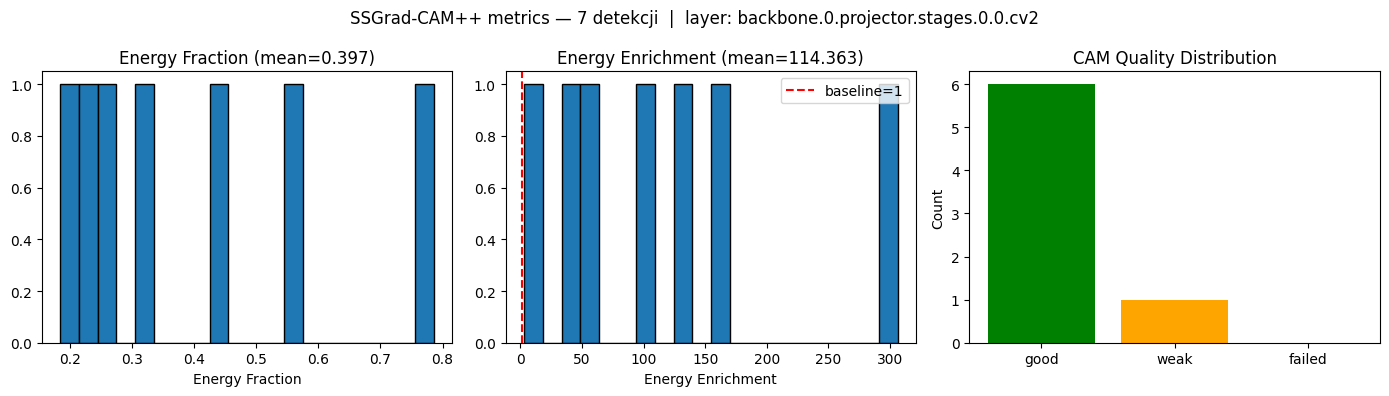

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/ssgradcampp_metric_distributions.png


In [69]:
if len(ok_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].hist(ok_df["energy_fraction"], bins=20, edgecolor="black")
    axes[0].set_xlabel("Energy Fraction")
    axes[0].set_title(f"Energy Fraction (mean={ok_df['energy_fraction'].mean():.3f})")

    axes[1].hist(ok_df["energy_enrichment"], bins=20, edgecolor="black")
    axes[1].axvline(1.0, color="red", linestyle="--", label="baseline=1")
    axes[1].set_xlabel("Energy Enrichment")
    axes[1].set_title(f"Energy Enrichment (mean={ok_df['energy_enrichment'].mean():.3f})")
    axes[1].legend()

    qual_counts = ok_df["cam_quality"].value_counts().reindex(["good", "weak", "failed"], fill_value=0)
    axes[2].bar(qual_counts.index, qual_counts.values, color=["green", "orange", "red"])
    axes[2].set_title("CAM Quality Distribution")
    axes[2].set_ylabel("Count")

    plt.suptitle(f"SSGrad-CAM++ metrics — {len(ok_df)} detekcji  |  layer: {TARGET_LAYER_NAME}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ssgradcampp_metric_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Zapisano: {OUTPUT_DIR / 'ssgradcampp_metric_distributions.png'}")

## Porównanie warstw projektora

SSGrad-CAM++ dla wybranych warstw `MultiScaleProjector` — wizualizacja w siatce:
każdy wiersz to jedna warstwa, kolumny: obraz+bbox | heatmapa+bbox | overlay+bbox.

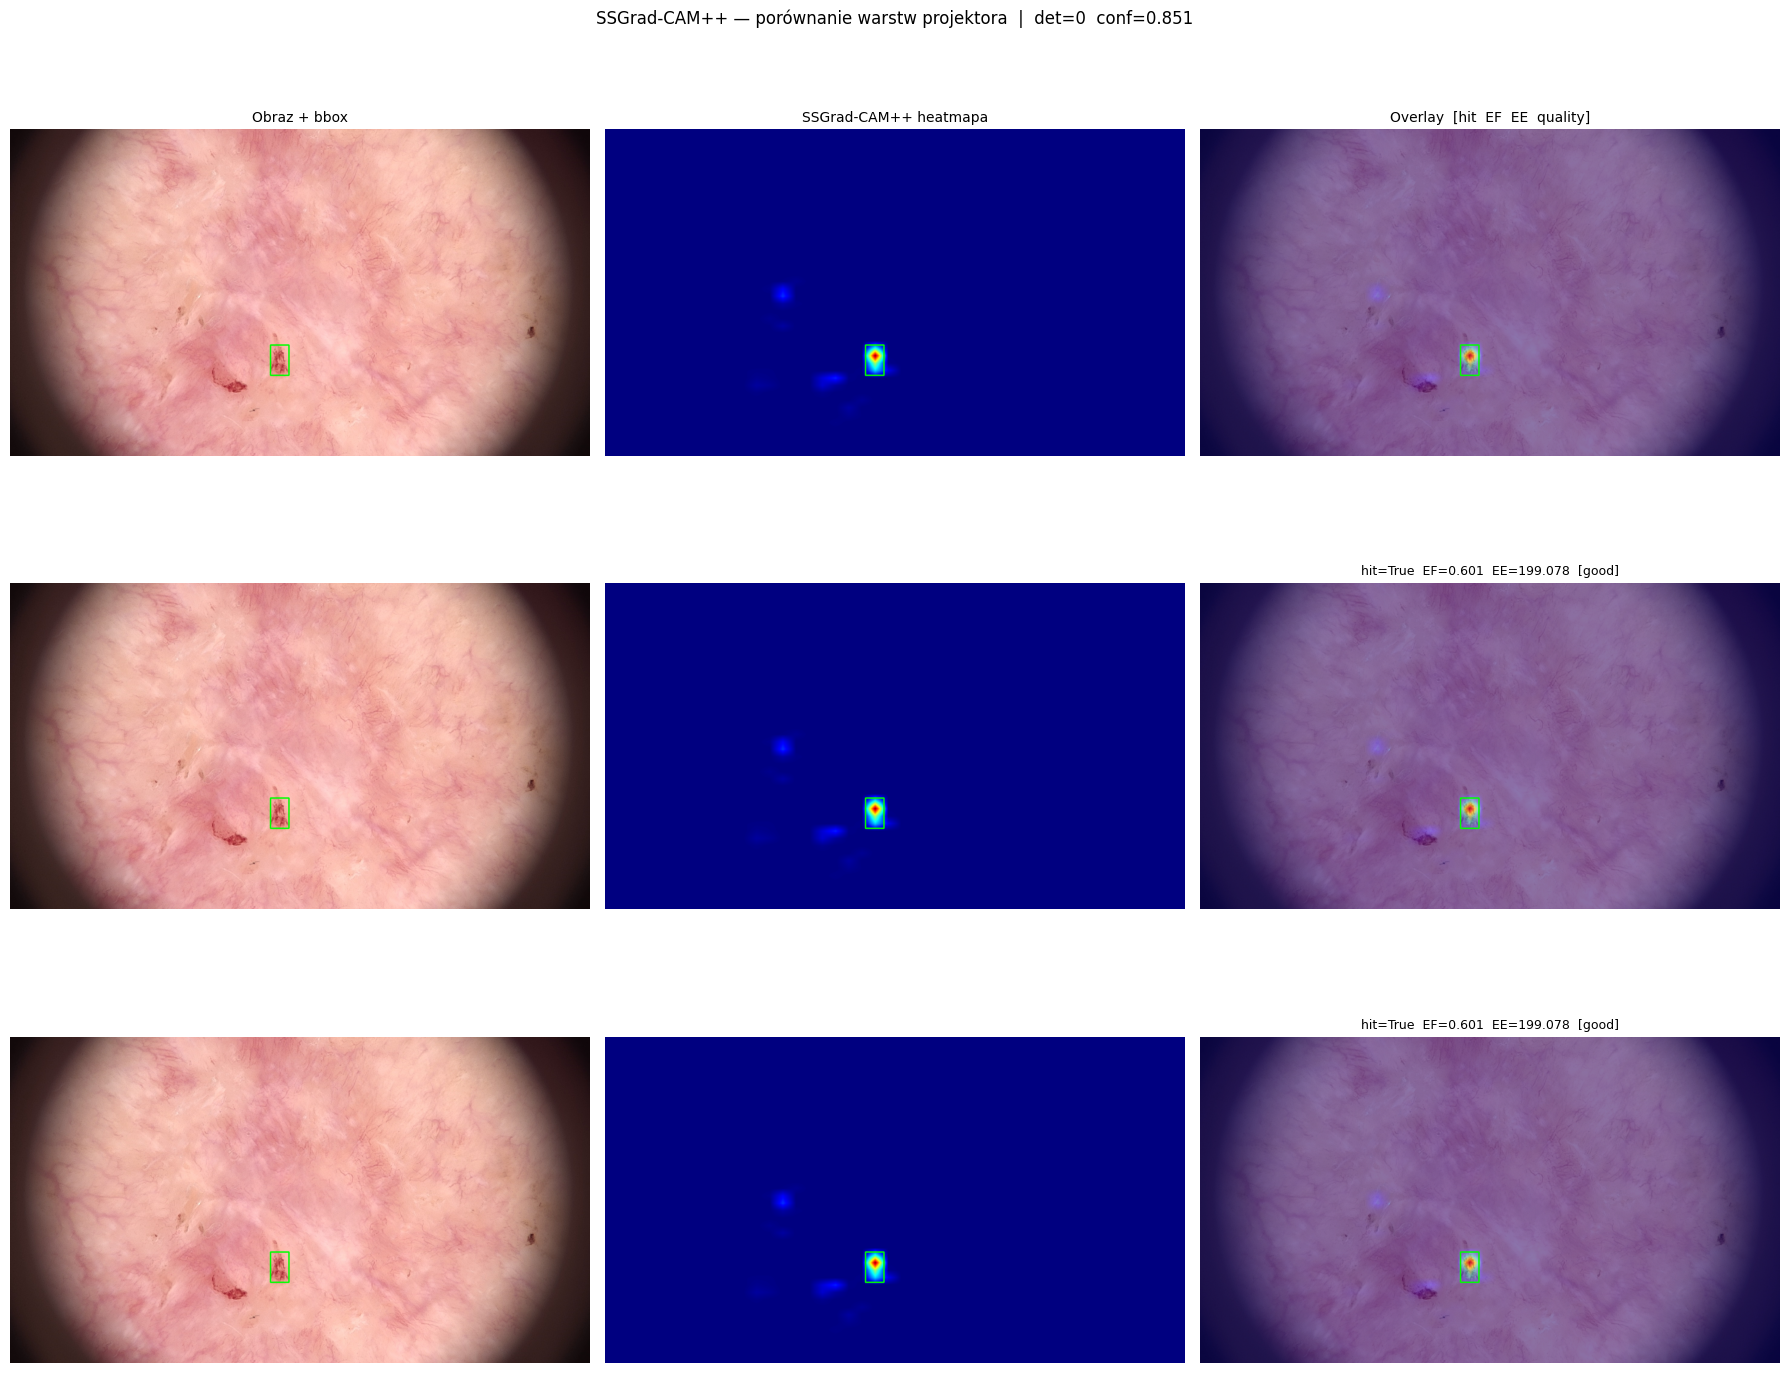

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/ssgradcampp_projector_sweep_det0.png

  backbone.0.projector                                     hit=True  EF=0.6012  EE=199.0776  [good]
  backbone.0.projector.stages.0                            hit=True  EF=0.6012  EE=199.0776  [good]
  backbone.0.projector.stages.0.1                          hit=True  EF=0.6012  EE=199.0776  [good]


In [70]:
PROJECTOR_LAYERS = [
    "backbone.0.projector",
    "backbone.0.projector.stages.0",
    "backbone.0.projector.stages.0.1",
]

# Detekcja do wizualizacji (domyślnie ta sama co DET_IDX)
VIS_DET_IDX = DET_IDX

assert det is not None and len(det) > VIS_DET_IDX, f"Brak detekcji det={VIS_DET_IDX}"

box_vis    = tuple(det.xyxy[VIS_DET_IDX].tolist())
img_box    = _draw_box(image_rgb, box_vis)

n_layers   = len(PROJECTOR_LAYERS)
fig, axes  = plt.subplots(n_layers, 3, figsize=(18, 5 * n_layers))

layer_results = []

for row, layer_name in enumerate(PROJECTOR_LAYERS):
    ax_img, ax_heat, ax_over = axes[row]

    try:
        cam_l, match_l = compute_rfdetr_ssgradcampp_for_detection(
            rf_model=model,
            batch_tensor=batch_tensor,
            pred_detections=det,
            det_index=VIS_DET_IDX,
            image_hw=image_hw,
            target_layer_name=layer_name,
            min_match_iou=MIN_MATCH_IOU,
            use_sigmoid_target=USE_SIGMOID_TARGET,
            class_aware=CLASS_AWARE,
        )

        hit_l = pointing_game_hit(cam_l, box_vis)
        ef_l  = energy_fraction_inside_bbox(cam_l, box_vis)
        ee_l  = energy_enrichment_inside_bbox(cam_l, box_vis)
        qual_l = cam_quality_status(hit_l, ef_l)

        layer_results.append({
            "layer": layer_name, "hit": hit_l, "ef": ef_l, "ee": ee_l, "quality": qual_l,
        })

        ax_img.imshow(img_box)
        ax_img.set_ylabel(layer_name.split("backbone.0.")[-1], fontsize=9, rotation=0, ha="right", va="center")

        ax_heat.imshow(draw_box_on_heatmap(cam_l, box_vis))

        ax_over.imshow(_draw_box(overlay_cam_on_image(image_rgb, cam_l, alpha=CAM_ALPHA), box_vis))
        ax_over.set_title(
            f"hit={hit_l}  EF={ef_l:.3f}  EE={ee_l:.3f}  [{qual_l}]",
            fontsize=9,
        )

        # Zapis indywidualnych wyników
        stem_l = f"ssgradcampp_det{VIS_DET_IDX}_{layer_name.replace('.', '_')}"
        save_ssgradcampp_result(
            image_rgb=image_rgb,
            cam=cam_l,
            match=match_l,
            class_name=class_label_for_id(model, match_l["pred_class_id"]),
            out_dir=OUTPUT_DIR / "projector_sweep",
            stem=stem_l,
            cam_quality=qual_l,
        )

    except Exception as exc:
        layer_results.append({"layer": layer_name, "error": str(exc)})
        for ax in (ax_img, ax_heat, ax_over):
            ax.text(0.5, 0.5, str(exc), ha="center", va="center", transform=ax.transAxes,
                    fontsize=8, color="red", wrap=True)
        ax_img.set_ylabel(layer_name.split("backbone.0.")[-1], fontsize=9, rotation=0, ha="right", va="center")

    for ax in (ax_img, ax_heat, ax_over):
        ax.axis("off")

# Nagłówki kolumn tylko w pierwszym wierszu
axes[0, 0].set_title("Obraz + bbox", fontsize=10)
axes[0, 1].set_title("SSGrad-CAM++ heatmapa", fontsize=10)
axes[0, 2].set_title("Overlay  [hit  EF  EE  quality]", fontsize=10)

fig.suptitle(
    f"SSGrad-CAM++ — porównanie warstw projektora  |  det={VIS_DET_IDX}  conf={det.confidence[VIS_DET_IDX]:.3f}",
    fontsize=12,
)
plt.tight_layout()

out_path = OUTPUT_DIR / f"ssgradcampp_projector_sweep_det{VIS_DET_IDX}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Zapisano: {out_path}")
print()
for r in layer_results:
    if "error" in r:
        print(f"  {r['layer']:55s}  ERROR: {r['error']}")
    else:
        print(f"  {r['layer']:55s}  hit={r['hit']}  EF={r['ef']:.4f}  EE={r['ee']:.4f}  [{r['quality']}]")

## Która warstwa jest ideologicznie właściwa?

**Kontekst architektury RF-DETR:**

```
DINOv2 (ViT-S/16)  →  MultiScaleProjector  →  Encoder (Transformer)  →  DETR head
      tokens [B,N,C]       C2f stages [B,C,H,W]      queries [B,Q,C]
```

`MultiScaleProjector` jest interfejsem między ViT a głowicą detekcji. Jego wyjścia to **jedyne** 4D mapy przestrzenne w całej architekturze RF-DETR — stąd też wszystkie CAM opierają się na tej samej rodzinie warstw.

| Warstwa | Uzasadnienie |
|---|---|
| `backbone.0.projector.stages.0.0.cv2` *(default)* | Wyjście projekcji C2f — pełna informacja po przetworzeniu bottlenecków; dobry kompromis semantyka/lokalizacja. |
| `backbone.0.projector.stages.0` / `backbone.0.projector` | Wyjście całego stage'a / całego projektora; niemal identyczne z `cv2` przy jednym stage. Przydatne jako sanity check. |
| `backbone.0.projector.stages.0.0.m.X.cv2` | Wewnętrzne bottlenecki C2f — bardziej lokalne receptive field, mogą dawać ostrzejsze mapy ale też bardziej szumowe. |

**Rekomendacja:** domyślnie `backbone.0.projector.stages.0.0.cv2` — to ostatnia warstwa projektora z wyjściem 4D, tuż przed encoderowym Transformerem. Wszelkie warstwy głębiej (encoder, decoder) są już 3D tokenowe bez naturalnej mapy przestrzennej.

> **Uwaga o tabeli z n=4:** n=4 oznacza tylko, że sweep był liczony na 4 detekcjach z jednego obrazu — nie traktuj tego jako finalnego rankingu. Poniżej sweep na większym batchu.

## Średnie statystyki warstw projektora — batch wieloobrazowy

Dla każdego obrazu (pierwsza detekcja) liczymy SSGrad-CAM++ na 3 warstwach z `PROJECTOR_LAYERS` i uśredniamy metryki. To pozwala ocenić stabilność każdej warstwy ponad zbiorem, a nie tylko na jednym obrazie.

In [71]:
PROJECTOR_SWEEP_MAX_IMAGES = None  # ustaw None dla pełnego zbioru

proj_image_list = sorted(Path(IMAGES_DIR).glob("*"))
if PROJECTOR_SWEEP_MAX_IMAGES is not None:
    proj_image_list = proj_image_list[:PROJECTOR_SWEEP_MAX_IMAGES]

print(f"Warstwy: {PROJECTOR_LAYERS}")
print(f"Obrazy:  {len(proj_image_list)}\n")

proj_rows = []

for img_idx, img_path in enumerate(proj_image_list):
    try:
        pil_i       = Image.open(img_path).convert("RGB")
        bt_i, orig_i, _ = preprocess_for_gradcampp(model, pil_i)
        det_i       = model.predict(pil_i, threshold=THRESHOLD)

        if det_i is None or len(det_i) == 0:
            print(f"[{img_idx:3d}] {img_path.name:40s}  brak detekcji")
            continue

        for layer_name in PROJECTOR_LAYERS:
            try:
                cam_p, match_p = compute_rfdetr_ssgradcampp_for_detection(
                    rf_model=model,
                    batch_tensor=bt_i,
                    pred_detections=det_i,
                    det_index=0,
                    image_hw=orig_i,
                    target_layer_name=layer_name,
                    min_match_iou=MIN_MATCH_IOU,
                    use_sigmoid_target=USE_SIGMOID_TARGET,
                    class_aware=CLASS_AWARE,
                )
                box_p  = tuple(match_p["box_orig_xyxy"])
                hit_p  = pointing_game_hit(cam_p, box_p)
                ef_p   = energy_fraction_inside_bbox(cam_p, box_p)
                ee_p   = energy_enrichment_inside_bbox(cam_p, box_p)
                proj_rows.append({
                    "img_idx"       : img_idx,
                    "image"         : img_path.name,
                    "layer"         : layer_name,
                    "matched_iou"   : round(match_p["matched_iou"], 4),
                    "pointing_game" : int(hit_p),
                    "energy_fraction"   : round(float(ef_p), 4),
                    "energy_enrichment" : round(float(ee_p), 4),
                    "cam_quality"   : cam_quality_status(hit_p, ef_p),
                    "status"        : "ok",
                })
            except Exception as exc:
                proj_rows.append({
                    "img_idx": img_idx, "image": img_path.name,
                    "layer": layer_name, "status": f"SKIP: {exc}",
                })

        print(f"[{img_idx:3d}] {img_path.name:40s}  ✓")

    except Exception as exc:
        print(f"[{img_idx:3d}] {img_path.name:40s}  ERROR: {exc}")

proj_df = pd.DataFrame(proj_rows)

proj_summary = (
    proj_df[proj_df["status"] == "ok"]
    .groupby("layer")
    .agg(
        n                   = ("img_idx", "count"),
        pointing_game_acc   = ("pointing_game", "mean"),
        mean_energy_fraction = ("energy_fraction", "mean"),
        mean_energy_enrichment = ("energy_enrichment", "mean"),
        mean_matched_iou    = ("matched_iou", "mean"),
        good_pct            = ("cam_quality", lambda x: (x == "good").mean()),
        weak_pct            = ("cam_quality", lambda x: (x == "weak").mean()),
        failed_pct          = ("cam_quality", lambda x: (x == "failed").mean()),
    )
    .sort_values("mean_energy_fraction", ascending=False)
    .round(4)
)

print("\n=== Średnie statystyki warstw projektora ===")
display(proj_summary)

proj_df.to_csv(OUTPUT_DIR / "projector_layer_sweep.csv", index=False)
print(f"\n✓ Zapisano: {OUTPUT_DIR / 'projector_layer_sweep.csv'}")

Warstwy: ['backbone.0.projector', 'backbone.0.projector.stages.0', 'backbone.0.projector.stages.0.1']
Obrazy:  217

[  0] 0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg  ✓
[  1] 065dc7c3-e5c9-43df-9bbd-0261e4ded209.jpg  ✓
[  2] 06712209-1128-4b89-b1d2-a7b02f6c0e01.jpg  brak detekcji
[  3] 069d7e58-1a48-42f2-ba20-8d8755278033.jpg  brak detekcji
[  4] 07bfc27f-44E4B9CA-6195-4709-AB33-93A433DA9451.jpg  brak detekcji
[  5] 0c0a8d26-29d7-4a83-9f1c-bd7d4eff83df.jpg  ✓
[  6] 0c7912ed-CF896695-C1EC-453B-8EAE-4F5AAF767DFF.jpg  brak detekcji
[  7] 0d5ea321-C1123C52-6700-407E-A3ED-558DC78F8F8B.jpg  brak detekcji
[  8] 0e98b2ca-24dd-45b2-95d9-914571a6a289.jpg  brak detekcji


[  9] 11e123d1-b9bf-4788-a9f9-246b0a003bf5.jpg  ✓
[ 10] 1279fd2b-74b0-4242-84aa-13dd1cc490b8.jpg  brak detekcji
[ 11] 135613c3-6452-41c3-b5b6-9c6c8cccaec6.jpg  ✓
[ 12] 13786df7-2c8e-4deb-b8a4-879223c67797.jpg  brak detekcji
[ 13] 14253804-1e4e-4d45-829a-4f84310ad5eb.jpg  ✓
[ 14] 148c7d92-64447989-C7EA-4706-BCAB-634706999A19.jpg  brak detekcji
[ 15] 15133615-91af-4361-8673-988e82cef7fb.jpg  brak detekcji
[ 16] 1532a0f5-baea-4f2a-9420-e75a5c7a009a.jpg  ✓
[ 17] 1707acdc-ceeb-414a-a6c9-aaf6f75e3906.jpg  brak detekcji
[ 18] 187a060d-05ed-4c72-8a56-a5726392243d.jpg  brak detekcji
[ 19] 1acc1d82-4c2c-4386-8ec2-d38276d7170e.jpg  brak detekcji
[ 20] 1b6568e0-ed0d-4be8-9e56-833fcbfbe166.jpg  brak detekcji
[ 21] 1c204ad2-eca4-4ce6-b77d-bdde592690cd.jpg  brak detekcji
[ 22] 1eb45872-4C09F1DD-FC7E-451C-8BC5-4F2B9F7A87E7.jpg  brak detekcji
[ 23] 1ef91e6f-d872-4f4c-b592-b34e91109434.jpg  ✓
[ 24] 1f17c568-808c-4abd-b7df-964024b0d434.jpg  brak detekcji
[ 25] 22353a51-6119-4a32-94e5-e582086adde2.jpg  ✓


,n,pointing_game_acc,mean_energy_fraction,mean_energy_enrichment,mean_matched_iou,good_pct,weak_pct,failed_pct
layer,,,,,,,,
backbone.0.projector.stages.0,87,0.7701,0.4249,61.6013,0.9993,0.7241,0.1609,0.1149
backbone.0.projector,87,0.7701,0.4249,61.6012,0.9993,0.7241,0.1609,0.1149
backbone.0.projector.stages.0.1,87,0.7701,0.4249,61.6006,0.9993,0.7241,0.1609,0.1149



✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/projector_layer_sweep.csv


## Finalny sweep kandydatów — duży batch

Sweep 3–5 najlepszych kandydatów na większej próbce (pierwsza detekcja per obraz). Po wyniku wybierz warstwę finalną i nadpisz `TARGET_LAYER_NAME` lub `SSGRADCAM_TARGET_LAYER_NAME` w komórce konfiguracji.

In [72]:
FINAL_LAYER_CANDIDATES = [
    "backbone.0.projector",
    "backbone.0.projector.stages.0",
    "backbone.0.projector.stages.0.0.cv2",
    "backbone.0.projector.stages.0.0.m.1.cv2",
    "backbone.0.projector.stages.0.0.m.2.cv2",
]

FINAL_SWEEP_MAX_IMAGES = None  # ustaw None dla pełnego zbioru

final_image_list = sorted(Path(IMAGES_DIR).glob("*"))
if FINAL_SWEEP_MAX_IMAGES is not None:
    final_image_list = final_image_list[:FINAL_SWEEP_MAX_IMAGES]

print(f"Kandydaci:  {FINAL_LAYER_CANDIDATES}")
print(f"Obrazy:     {len(final_image_list)}\n")

final_rows = []

for img_idx, img_path in enumerate(final_image_list):
    try:
        pil_i        = Image.open(img_path).convert("RGB")
        bt_i, orig_i, _ = preprocess_for_gradcampp(model, pil_i)
        det_i        = model.predict(pil_i, threshold=THRESHOLD)

        if det_i is None or len(det_i) == 0:
            print(f"[{img_idx:3d}] {img_path.name:40s}  brak detekcji")
            continue

        for layer_name in FINAL_LAYER_CANDIDATES:
            try:
                cam_f, match_f = compute_rfdetr_ssgradcampp_for_detection(
                    rf_model=model,
                    batch_tensor=bt_i,
                    pred_detections=det_i,
                    det_index=0,
                    image_hw=orig_i,
                    target_layer_name=layer_name,
                    min_match_iou=MIN_MATCH_IOU,
                    use_sigmoid_target=USE_SIGMOID_TARGET,
                    class_aware=CLASS_AWARE,
                )
                box_f  = tuple(match_f["box_orig_xyxy"])
                hit_f  = pointing_game_hit(cam_f, box_f)
                ef_f   = energy_fraction_inside_bbox(cam_f, box_f)
                ee_f   = energy_enrichment_inside_bbox(cam_f, box_f)
                final_rows.append({
                    "img_idx"           : img_idx,
                    "image"             : img_path.name,
                    "layer"             : layer_name,
                    "matched_iou"       : round(match_f["matched_iou"], 4),
                    "pointing_game"     : int(hit_f),
                    "energy_fraction"   : round(float(ef_f), 4),
                    "energy_enrichment" : round(float(ee_f), 4),
                    "cam_quality"       : cam_quality_status(hit_f, ef_f),
                    "status"            : "ok",
                })
            except Exception as exc:
                final_rows.append({
                    "img_idx": img_idx, "image": img_path.name,
                    "layer": layer_name, "status": f"SKIP: {exc}",
                })

        print(f"[{img_idx:3d}] {img_path.name:40s}  ✓  ({len(det_i)} det)")

    except Exception as exc:
        print(f"[{img_idx:3d}] {img_path.name:40s}  ERROR: {exc}")

final_df = pd.DataFrame(final_rows)

final_summary = (
    final_df[final_df["status"] == "ok"]
    .groupby("layer")
    .agg(
        n                       = ("img_idx", "count"),
        pointing_game_acc       = ("pointing_game", "mean"),
        mean_energy_fraction    = ("energy_fraction", "mean"),
        mean_energy_enrichment  = ("energy_enrichment", "mean"),
        mean_matched_iou        = ("matched_iou", "mean"),
        good_pct                = ("cam_quality", lambda x: (x == "good").mean()),
        weak_pct                = ("cam_quality", lambda x: (x == "weak").mean()),
        failed_pct              = ("cam_quality", lambda x: (x == "failed").mean()),
    )
    .sort_values("mean_energy_fraction", ascending=False)
    .round(4)
)

print("\n=== Finalny ranking warstw ===")
display(final_summary)

final_df.to_csv(OUTPUT_DIR / "final_layer_candidates_sweep.csv", index=False)
print(f"\n✓ Zapisano: {OUTPUT_DIR / 'final_layer_candidates_sweep.csv'}")

best_layer = final_summary.index[0]
print(f"\n→ Najlepsza warstwa wg mean_energy_fraction: {best_layer!r}")
print("  Jeśli wynik jest stabilny, wklej tę nazwę do SSGRADCAM_TARGET_LAYER_NAME w komórce konfiguracji.")

Kandydaci:  ['backbone.0.projector', 'backbone.0.projector.stages.0', 'backbone.0.projector.stages.0.0.cv2', 'backbone.0.projector.stages.0.0.m.1.cv2', 'backbone.0.projector.stages.0.0.m.2.cv2']
Obrazy:     217



[  0] 0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg  ✓  (4 det)
[  1] 065dc7c3-e5c9-43df-9bbd-0261e4ded209.jpg  ✓  (1 det)
[  2] 06712209-1128-4b89-b1d2-a7b02f6c0e01.jpg  brak detekcji
[  3] 069d7e58-1a48-42f2-ba20-8d8755278033.jpg  brak detekcji
[  4] 07bfc27f-44E4B9CA-6195-4709-AB33-93A433DA9451.jpg  brak detekcji
[  5] 0c0a8d26-29d7-4a83-9f1c-bd7d4eff83df.jpg  ✓  (1 det)
[  6] 0c7912ed-CF896695-C1EC-453B-8EAE-4F5AAF767DFF.jpg  brak detekcji
[  7] 0d5ea321-C1123C52-6700-407E-A3ED-558DC78F8F8B.jpg  brak detekcji
[  8] 0e98b2ca-24dd-45b2-95d9-914571a6a289.jpg  brak detekcji
[  9] 11e123d1-b9bf-4788-a9f9-246b0a003bf5.jpg  ✓  (3 det)
[ 10] 1279fd2b-74b0-4242-84aa-13dd1cc490b8.jpg  brak detekcji
[ 11] 135613c3-6452-41c3-b5b6-9c6c8cccaec6.jpg  ✓  (1 det)
[ 12] 13786df7-2c8e-4deb-b8a4-879223c67797.jpg  brak detekcji
[ 13] 14253804-1e4e-4d45-829a-4f84310ad5eb.jpg  ✓  (1 det)
[ 14] 148c7d92-64447989-C7EA-4706-BCAB-634706999A19.jpg  brak detekcji
[ 15] 15133615-91af-4361-8673-988e82cef7fb.jpg  brak

KeyboardInterrupt: 

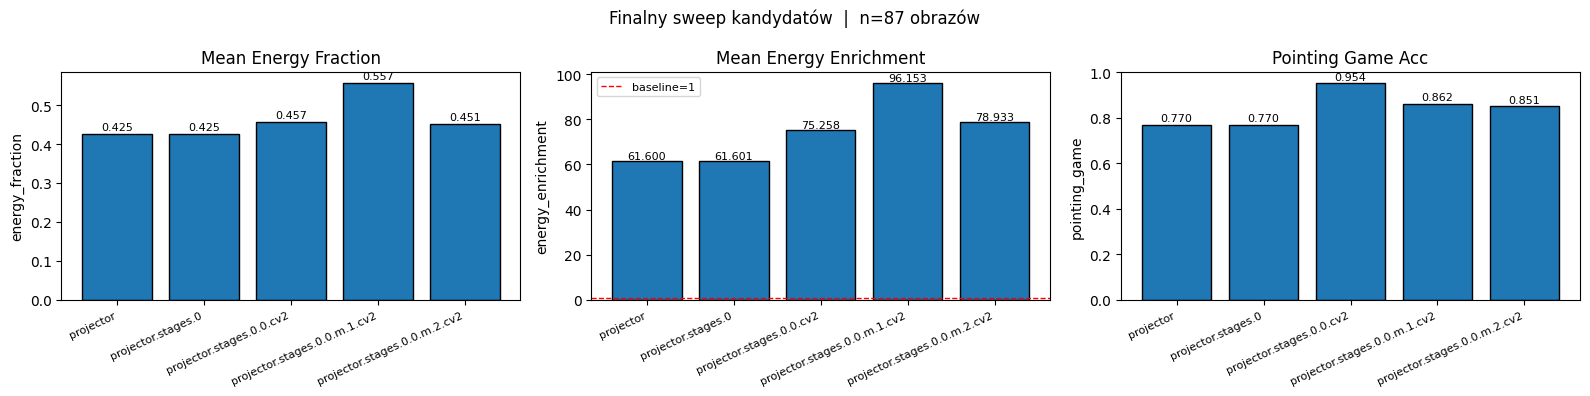

✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/final_layer_candidates_barplot.png


In [ ]:
# Wykres słupkowy: porównanie metryk między kandydatami
ok_final = final_df[final_df["status"] == "ok"].copy()

if len(ok_final) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, metric, label in [
        (axes[0], "energy_fraction",   "Mean Energy Fraction"),
        (axes[1], "energy_enrichment", "Mean Energy Enrichment"),
        (axes[2], "pointing_game",     "Pointing Game Acc"),
    ]:
        vals = ok_final.groupby("layer")[metric].mean().reindex(FINAL_LAYER_CANDIDATES)
        short_names = [n.replace("backbone.0.", "") for n in vals.index]
        bars = ax.bar(range(len(vals)), vals.values, edgecolor="black")
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels(short_names, rotation=25, ha="right", fontsize=8)
        ax.set_title(label)
        ax.set_ylabel(metric)
        if metric == "energy_enrichment":
            ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="baseline=1")
            ax.legend(fontsize=8)
        for bar, val in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    fig.suptitle(f"Finalny sweep kandydatów  |  n={len(ok_final['img_idx'].unique())} obrazów", fontsize=12)
    plt.tight_layout()
    out_path = OUTPUT_DIR / "final_layer_candidates_barplot.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Zapisano: {out_path}")

[ 1/10] c6114f6a-ed61-4600-b7db-c0c2513f6e03.jpg
[ 4/10] e0dc3820-3358A6F0-24C4-40F6-AE29-9DE40C2A7308.jpg
[ 5/10] 50dba128-833e-4e37-8995-f7933e67d751.jpg
[ 7/10] 3c87dc20-833d-4b58-a0da-d1591fc827c8.jpg
[ 8/10] 30b405d3-fa6b-43ca-843b-6e9dfa903392.jpg


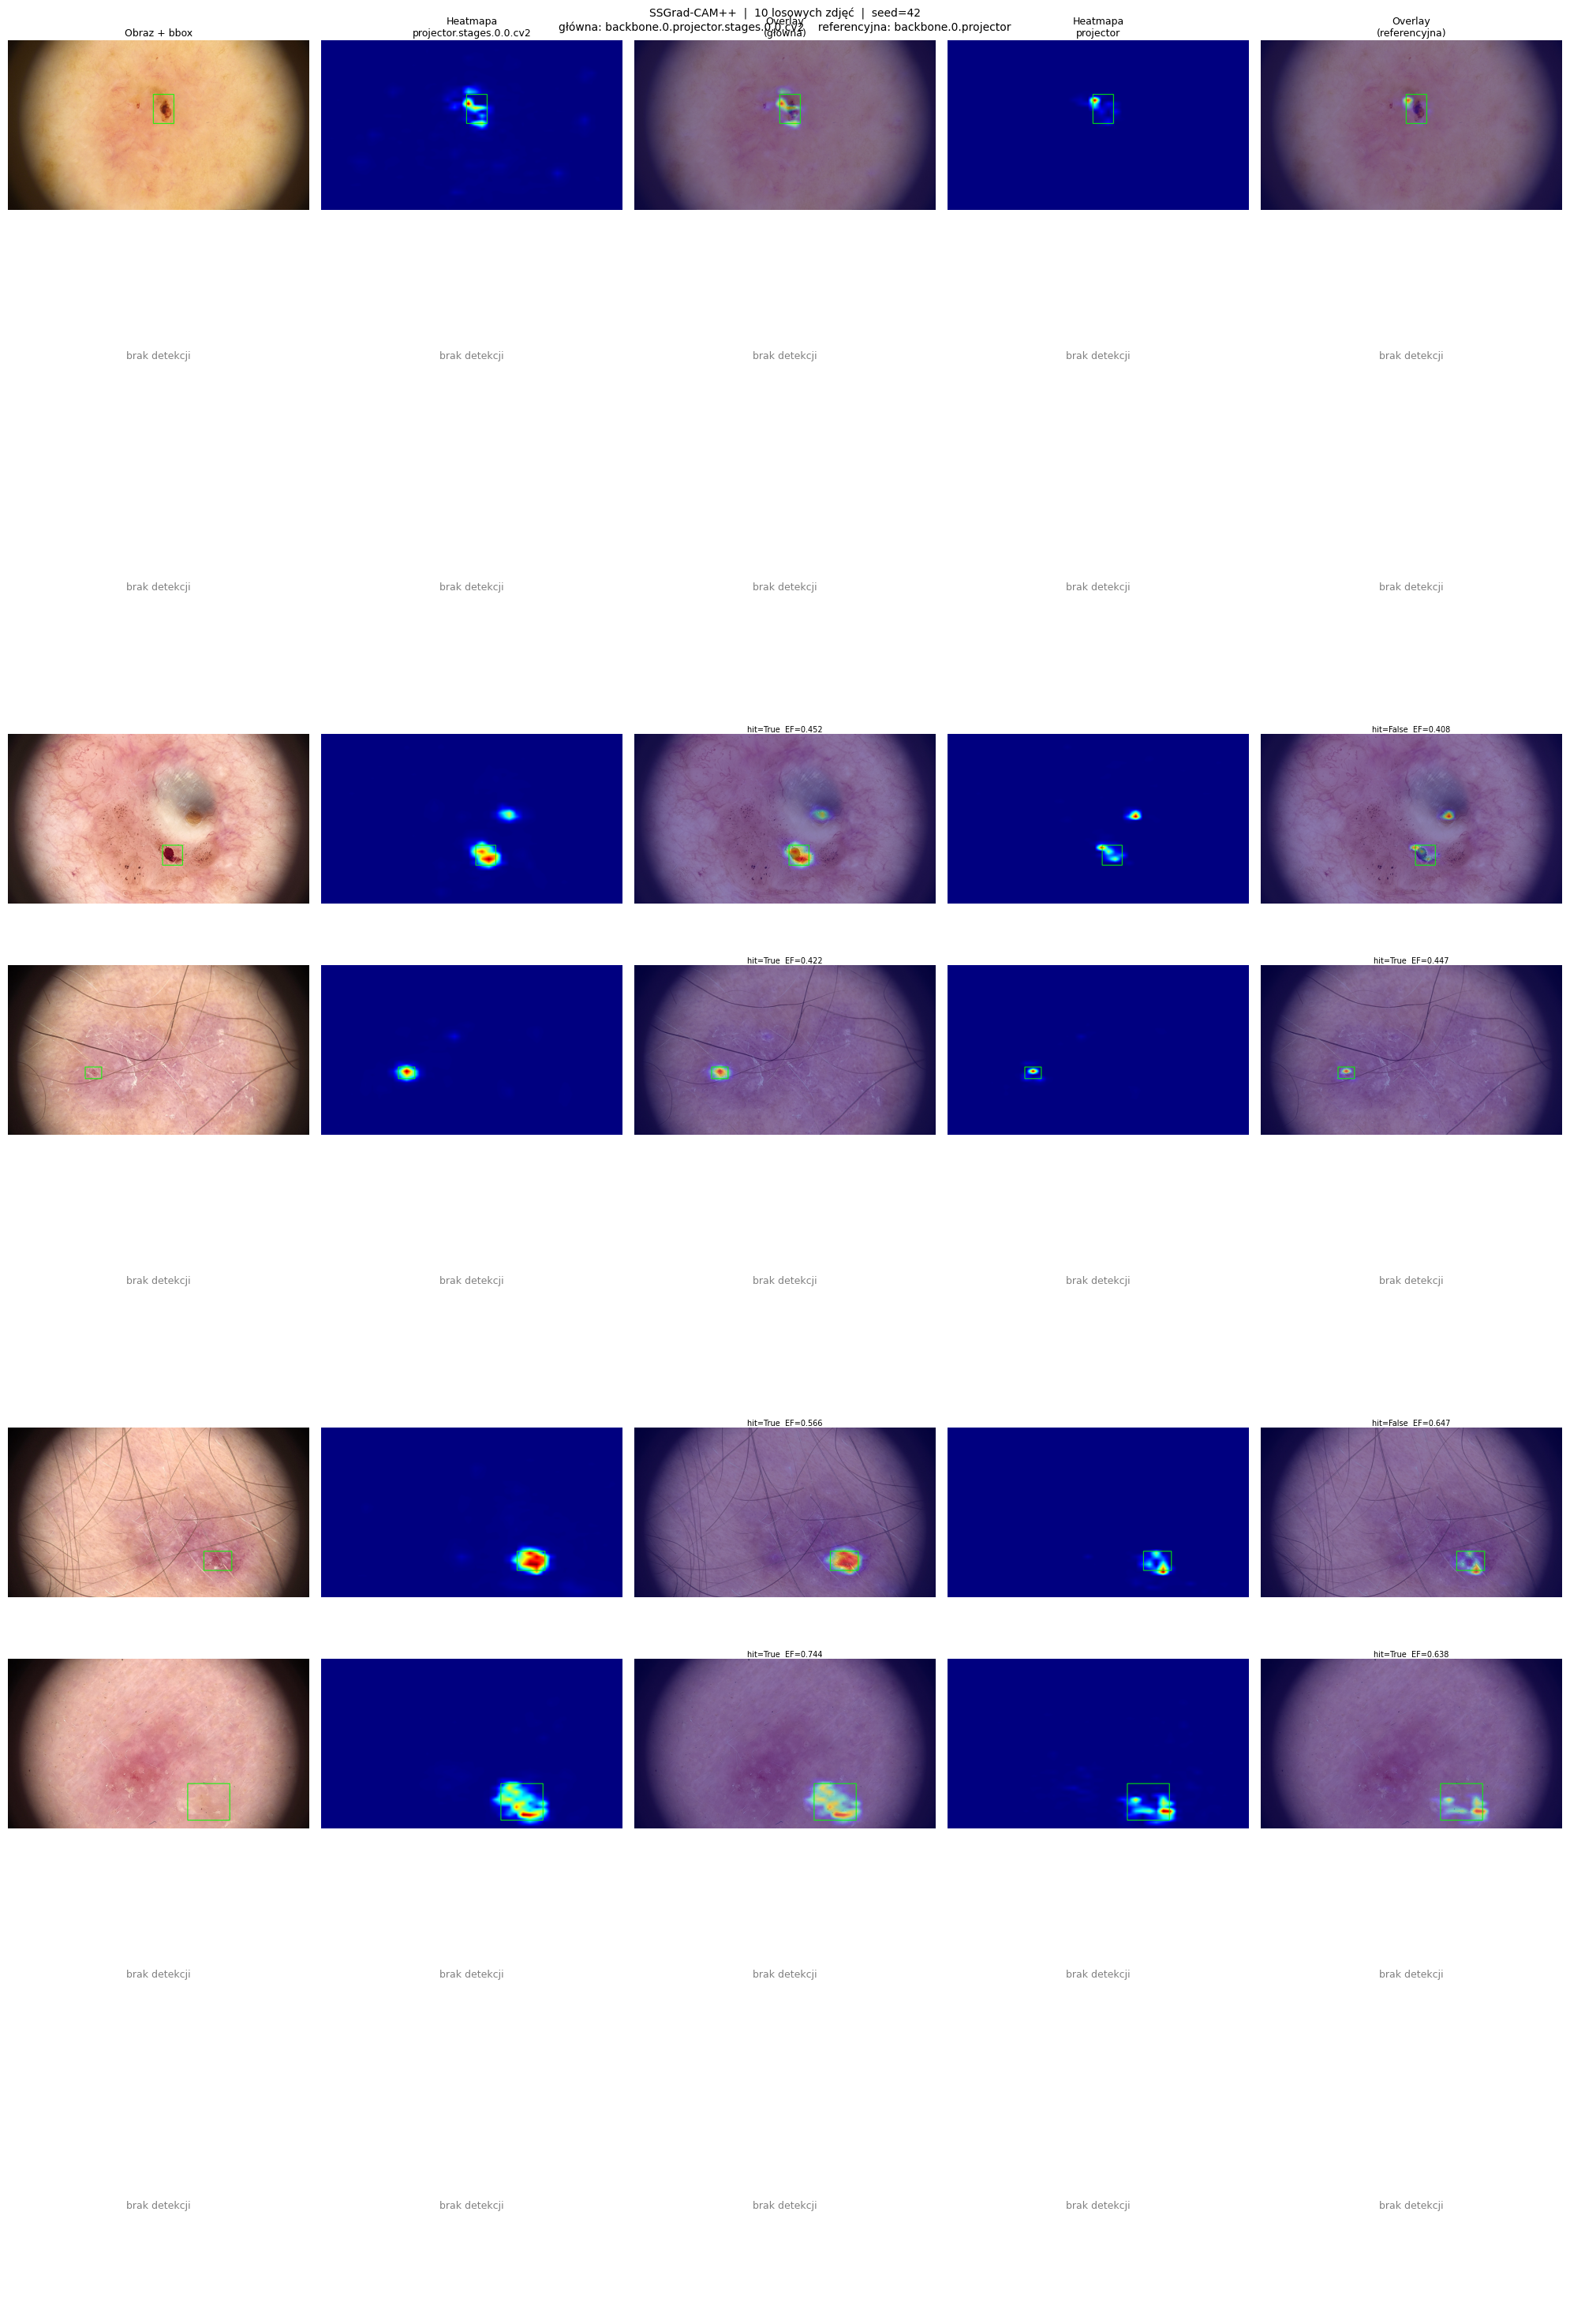


✓ Zapisano: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_ssgradcampp/ssgradcampp_random10_grid.png


In [73]:
import random

RANDOM_VIS_N    = 10
RANDOM_VIS_SEED = 42

all_img_paths = sorted(Path(IMAGES_DIR).glob("*"))

# Filtruj do obrazów z co najmniej jedną detekcją powyżej THRESHOLD
print("Filtrowanie obrazów z detekcjami...")
imgs_with_det = []
for _p in all_img_paths:
    try:
        _pil = Image.open(_p).convert("RGB")
        _det = model.predict(_pil, threshold=THRESHOLD)
        if _det is not None and len(_det) > 0:
            imgs_with_det.append(_p)
    except Exception:
        pass
print(f"  {len(imgs_with_det)}/{len(all_img_paths)} obrazów ma detekcje (threshold={THRESHOLD})\n")

rng = random.Random(RANDOM_VIS_SEED)
sample_paths = rng.sample(imgs_with_det, min(RANDOM_VIS_N, len(imgs_with_det)))

# kolumny: orig+bbox | heatmap MAIN | overlay MAIN | heatmap REF | overlay REF
COL_LABELS = [
    "Obraz + bbox",
    f"Heatmapa\n{TARGET_LAYER_MAIN.split('backbone.0.')[-1]}",
    f"Overlay\n(główna)",
    f"Heatmapa\n{TARGET_LAYER_REF.split('backbone.0.')[-1]}",
    f"Overlay\n(referencyjna)",
]
N_COLS = len(COL_LABELS)
N_ROWS = len(sample_paths)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 4, N_ROWS * 3))

for row, img_path in enumerate(sample_paths):
    axrow = axes[row]

    try:
        pil_s        = Image.open(img_path).convert("RGB")
        img_s        = np.array(pil_s)
        bt_s, orig_s, _ = preprocess_for_gradcampp(model, pil_s)
        det_s        = model.predict(pil_s, threshold=THRESHOLD)

        box_s = tuple(det_s.xyxy[0].tolist())

        # Oblicz CAM dla obu warstw
        cams = {}
        for layer_name in (TARGET_LAYER_MAIN, TARGET_LAYER_REF):
            try:
                cam_s, match_s = compute_rfdetr_ssgradcampp_for_detection(
                    rf_model=model,
                    batch_tensor=bt_s,
                    pred_detections=det_s,
                    det_index=0,
                    image_hw=orig_s,
                    target_layer_name=layer_name,
                    min_match_iou=MIN_MATCH_IOU,
                    use_sigmoid_target=USE_SIGMOID_TARGET,
                    class_aware=CLASS_AWARE,
                )
                cams[layer_name] = cam_s
            except Exception as exc:
                cams[layer_name] = str(exc)

        # col 0: obraz + bbox
        axrow[0].imshow(_draw_box(img_s, box_s))
        axrow[0].set_ylabel(img_path.stem[:22], fontsize=7, rotation=0,
                            ha="right", va="center")

        # cols 1–2: główna
        cam_main = cams[TARGET_LAYER_MAIN]
        if isinstance(cam_main, str):
            axrow[1].text(0.5, 0.5, cam_main, ha="center", va="center",
                          transform=axrow[1].transAxes, fontsize=7, color="red")
            axrow[2].axis("off")
        else:
            ef_m  = energy_fraction_inside_bbox(cam_main, box_s)
            hit_m = pointing_game_hit(cam_main, box_s)
            axrow[1].imshow(draw_box_on_heatmap(cam_main, box_s))
            axrow[2].imshow(_draw_box(overlay_cam_on_image(img_s, cam_main, alpha=CAM_ALPHA), box_s))
            axrow[2].set_title(f"hit={hit_m}  EF={ef_m:.3f}", fontsize=7, pad=2)

        # cols 3–4: referencyjna
        cam_ref = cams[TARGET_LAYER_REF]
        if isinstance(cam_ref, str):
            axrow[3].text(0.5, 0.5, cam_ref, ha="center", va="center",
                          transform=axrow[3].transAxes, fontsize=7, color="red")
            axrow[4].axis("off")
        else:
            ef_r  = energy_fraction_inside_bbox(cam_ref, box_s)
            hit_r = pointing_game_hit(cam_ref, box_s)
            axrow[3].imshow(draw_box_on_heatmap(cam_ref, box_s))
            axrow[4].imshow(_draw_box(overlay_cam_on_image(img_s, cam_ref, alpha=CAM_ALPHA), box_s))
            axrow[4].set_title(f"hit={hit_r}  EF={ef_r:.3f}", fontsize=7, pad=2)

    except Exception as exc:
        for ax in axrow:
            ax.text(0.5, 0.5, str(exc), ha="center", va="center",
                    transform=ax.transAxes, fontsize=7, color="red")

    for ax in axrow:
        ax.axis("off")

    print(f"[{row+1:2d}/{N_ROWS}] {img_path.name}")

# Nagłówki kolumn
for col_idx, label in enumerate(COL_LABELS):
    axes[0, col_idx].set_title(label, fontsize=9, pad=4)

fig.suptitle(
    f"SSGrad-CAM++  |  {N_ROWS} losowych zdjęć  |  seed={RANDOM_VIS_SEED}\n"
    f"główna: {TARGET_LAYER_MAIN}    referencyjna: {TARGET_LAYER_REF}",
    fontsize=10,
)
plt.tight_layout()
out_grid = OUTPUT_DIR / f"ssgradcampp_random{N_ROWS}_grid.png"
fig.savefig(out_grid, dpi=120, bbox_inches="tight")
plt.show()
print(f"\n✓ Zapisano: {out_grid}")

## Podsumowanie wyboru warstwy docelowej

Wizualizacja 10 losowych zdjęć potwierdza trzy obserwacje:

1. **Warstwa projektora** (`backbone.0.projector`) daje sensowne mapy i jest najłatwiejsza do obrony metodologicznie jako naturalne wyjście między DINOv2 a głowicą detekcyjną.
2. **Warstwa empiryczna** (`backbone.0.projector.stages.0.0.cv2`) często daje ostrzejsze, bardziej skoncentrowane mapy.
3. **Wewnętrzne warstwy typu `m.1.cv2`** mogą dawać najwyższy *Energy Fraction*, ale są mniej eleganckie jako domyślny wybór, bo mocniej zależą od konkretnej implementacji bloku C2f.

### Wyniki sweepu (batch)

```text
backbone.0.projector  /  backbone.0.projector.stages.0:
  EF ≈ 0.425  |  EE ≈ 61.6  |  PG ≈ 0.770

backbone.0.projector.stages.0.0.cv2:
  EF ≈ 0.457  |  EE ≈ 75.3  |  PG ≈ 0.954   ← najlepsza trafność maksimum

backbone.0.projector.stages.0.0.m.1.cv2:
  EF ≈ 0.557  |  EE ≈ 96.2  |  PG ≈ 0.862   ← najwyższe skupienie, mniej stabilne
```

`stages.0.0.cv2` ma **najlepszą trafność Pointing Game (0.954)** i wygląda stabilniej jako mapa lokalizacyjna. Dlatego jest wybrana jako warstwa finalna.

### Konfiguracja finalna

```python
TARGET_LAYER_MAIN = "backbone.0.projector.stages.0.0.cv2"  # finalna
TARGET_LAYER_REF  = "backbone.0.projector"                  # referencyjna / ablacyjna
```

### Uzasadnienie metodologiczne

Wybór ograniczono do rodziny `backbone.0.projector...`, ponieważ warstwy te:
- zachowują naturalną mapę przestrzenną `[B, C, H, W]` (wszystkie warstwy głębiej są tokenowe `[B, N, C]`)
- leżą pomiędzy ekstraktorem cech DINOv2 a częścią detekcyjną modelu
- są semantycznie uzasadnione jako interfejs backbone → detektor

Wybór warstwy opieramy na **swepie po semantycznie uzasadnionych warstwach projektora** — nie jest to cherry-picking w całym modelu.

### Tekst do README / pracy

**PL:**
> Jako warstwę docelową dla SSGrad-CAM++ wybrano `backbone.0.projector.stages.0.0.cv2` na podstawie sweepu po warstwach projektora RF-DETR (jedynych zachowujących przestrzenną mapę cech `[B,C,H,W]`). Warstwa ta osiągnęła najwyższą skuteczność *Pointing Game* i wysoką koncentrację energii mapy w obszarach detekcji. `backbone.0.projector` traktujemy jako warstwę referencyjną/ablacyjną.

**EN:**
> The layer `backbone.0.projector.stages.0.0.cv2` was selected as the SSGrad-CAM++ target through a sweep over RF-DETR projector layers — the only layers preserving a spatial feature map `[B,C,H,W]`. It achieved the highest Pointing Game accuracy and strong energy concentration within target detections. `backbone.0.projector` is retained as a reference/ablation layer.

### Podpis do slajdu

> SSGrad-CAM++ generuje stabilne wyjaśnienia na poziomie detekcji. Warstwa `stages.0.0.cv2` daje ostrzejsze i częściej poprawnie zlokalizowane mapy niż ogólne wyjście projektora, przy zachowaniu tego samego mechanizmu dopasowania detekcji do query RF-DETR.
>
> **Final layer:** `backbone.0.projector.stages.0.0.cv2` — **Reference layer:** `backbone.0.projector`